# Order Book Signals on Bond & Equity Calendar Spreads

## Setup

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')

import polars as pl
import polars.selectors as cs
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from plotnine import *
from plotnine.themes import theme_bw

from src.utils import (
    connect_snowflake,
    create_snowpark_session,
    retrieve_polars_from_snowpark,
    unpack_kwargs,
    unpack_kwargs_for_agg,
    read_table,
    parse_security,
    build_contract_calendar,
    add_roll_window,
    add_microstructure_signals,
    acf_by_security,
    ljungbox_by_security,
)
from snowflake.snowpark import functions as F
from snowflake.snowpark.window import Window
from functools import reduce
import operator

# --- Chronological out-of-sample split (by trading-data year), used throughout ----------
# Defined here so EVERY downstream transform can reference the SAME train partition — in
# particular the within-train z-score padding in the normalisation step, which must not pull
# statistics from validation/test rows.
TRAIN_YEARS = [2021, 2022, 2023]
VAL_YEARS   = [2024]
TEST_YEARS  = [2025]
YEAR_LABEL  = {'train': '2021-2023', 'val': '2024', 'test': '2025'}

pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_rows(20)
print('polars', pl.__version__)

In [ ]:
DB     = 'LISTED_INTERN_PROJECT'
SCHEMA = 'PROJECT_5'
TABLES = ['BINNED_DATA', 'QCODE_MAPPING', 'SECURITY_META']

snowflake_conn = connect_snowflake('../.env')
snowpark = create_snowpark_session('../.env')
print('Connected.')

In [ ]:
# Data subset: Years 2021-2025 (narrowed to the chosen years in the preprocessing step).

BINNED_COLS = [
    'QCODE', 'SECURITY', 'BIN_START_TIME', 'PUBLICATION_DATE',
    'BID_SIZE_START', 'ASK_SIZE_START', 'BID_START', 'ASK_START',
    'VOLUME', 'SIGNED_VOLUME',
]
QCODE_COLS    = ['QCODE', 'BBG_CODE', 'YELLOW_KEY', 'DELIVERY', 'IS_CONVENTION_BUY_NEAR']
SEC_META_COLS = ['SECURITY', 'LAST_TRADE_DATE', 'FIRST_NOTICE_DATE']

qmap     = read_table(snowpark, DB, SCHEMA, 'QCODE_MAPPING', QCODE_COLS)
sec_meta = read_table(snowpark, DB, SCHEMA, 'SECURITY_META', SEC_META_COLS)

phys_qcodes = qmap.filter(pl.col('delivery') == 'Phys')['qcode'].unique().to_list()
cash_qcodes = qmap.filter(pl.col('delivery') == 'Cash')['qcode'].unique().to_list()
subset_qcodes = phys_qcodes + cash_qcodes
print(f'Phys qcodes : {phys_qcodes}')
print(f'Cash qcodes : {cash_qcodes}')

# BBG_CODE + YELLOW_KEY — used to construct the spread filter.
subset_products = (
    qmap.filter(pl.col('qcode').is_in(subset_qcodes))
    .select('bbg_code', 'yellow_key')
    .unique()
)

fqn_binned = f'{DB}.{SCHEMA}.BINNED_DATA'

# Futures: QCODE in our subset AND SECURITY has no slash (LIKE '%/%' negated).
futures_filter = (
    F.col('QCODE').isin(subset_qcodes) &
    ~F.col('SECURITY').like('%/%')
)

# Spreads: SECURITY matches pattern  {BBG_CODE}.../{...} {YELLOW_KEY}.
# Using Snowflake LIKE: '%' = zero-or-more wildcard characters.

spread_clauses = [
    F.col('SECURITY').like(f'{row["bbg_code"]}%/% {row["yellow_key"]}')
    for row in subset_products.iter_rows(named=True)
]
spread_filter = reduce(operator.or_, spread_clauses)

snow_binned = (
    snowpark.table(fqn_binned)
    .select(*BINNED_COLS)
    .filter(futures_filter | spread_filter)
)
binned = retrieve_polars_from_snowpark(snow_binned)

n_fut = binned.filter(~pl.col('security').str.contains('/')).height
n_spr = binned.filter(pl.col('security').str.contains('/')).height
print(f'binned   : {binned.shape}  (futures: {n_fut:,}  |  spreads: {n_spr:,})')
print(f'qmap     : {qmap.shape}')
print(f'sec_meta : {sec_meta.shape}')

## Preprocessing
Outputs:
- `df_cs` — filtered calendar spreads only.
- `df_combined` — filtered calendar spreads **and** filtered futures.

In [ ]:
# Step 1: merge BINNED_DATA with QCODE_MAPPING on QCODE.
# Spreads pulled via the name-pattern filter may have QCODEs outside subset_qcodes,
# so their bbg_code / yellow_key / delivery / is_convention_buy_near will be null here.
data = binned.join(qmap, on='qcode', how='left')

# Step 2: parse SECURITY -> is_spread, near/far identifiers, meta_key.
data = parse_security(data, col='security')

data.head()

# Steps 3-4: build the per-future roll calendar (target date + own/previous roll windows).
calendar = build_contract_calendar(sec_meta, qmap, roll_days=10)

# Drop qmap's 'delivery' before joining the calendar so the calendar's 'delivery'
# (correctly resolved from BBG_CODE+YELLOW_KEY for every security) is the sole authority.
data = data.drop('delivery')
data = data.join(
    calendar.rename({'security': 'meta_key'}),
    on='meta_key',
    how='left',
)

# Step 5: trading date from PUBLICATION_DATE (BIN_START_TIME is time-only, not a date).
data = data.with_columns(date=pl.col('publication_date').cast(pl.Date))

# Step 6: keep rows whose trading date (PUBLICATION_DATE year) is 2021-2025 inclusive.
# These years feed the chronological OOS split downstream:
#   train = 2021-2023, validation = 2024, test = 2025.
data = data.filter(pl.col('publication_date').dt.year().is_in([2021, 2022, 2023, 2024, 2025]))

n_spread = data.filter(pl.col('is_spread')).height
print(f'rows: {data.height:,}  |  spread rows: {n_spread:,}  |  future rows: {data.height - n_spread:,}')
data.select(
    'security', 'is_spread', 'near_identifier', 'far_identifier', 'meta_key',
    'delivery', 'target_date', 'roll_start', 'roll_end', 'prev_roll_start', 'prev_roll_end',
).head()

In [ ]:
# A bin sits inside a [start, end] window (inclusive). Null bounds (missing metadata) -> False.
def _in_window(start: str, end: str) -> pl.Expr:
    return pl.col('date').is_between(pl.col(start), pl.col(end), closed='both').fill_null(False)

in_own_roll  = _in_window('roll_start', 'roll_end')
in_prev_roll = _in_window('prev_roll_start', 'prev_roll_end')

# Calendar spreads: own (near-leg) roll period only.
df_cs = data.filter(pl.col('is_spread') & in_own_roll)

# Futures: own roll period OR previous contract's roll period.
df_fut = data.filter(~pl.col('is_spread') & (in_own_roll | in_prev_roll))

# Combined: filtered spreads + filtered futures (aligned schema via vertical concat).
df_combined = pl.concat([df_cs, df_fut], how='vertical')

print(f'df_cs       : {df_cs.shape}')
print(f'df_fut      : {df_fut.shape}')
print(f'df_combined : {df_combined.shape}')
df_cs.head()

In [ ]:
# roll period is when daily volume exceeds 25% of daily max for same security

daily_volume = df_cs.group_by('security', 'date').agg(daily_vol=pl.col('volume').sum())

max_volume = daily_volume.group_by('security').agg(max_daily_vol=pl.col('daily_vol').max())

df_cs = df_cs.join(daily_volume, on=['security', 'date'], how='left')
df_cs = df_cs.join(max_volume, on='security', how='left')
df_cs = df_cs.with_columns(
    is_roll_period=(pl.col('daily_vol') >= 0.25 * pl.col('max_daily_vol'))
).drop(['daily_vol', 'max_daily_vol'])

df_cs = df_cs.filter(pl.col('is_roll_period'))

## Signal Generation

Using the per-bin `*_START` quotes:

| Signal | Definition |
|---|---|
| $P_t$ (`mid_price`) | $(\text{BID\_START} + \text{ASK\_START})/2$ |
| $\Delta P_t$ (`delta_p`) | $P_t - P_{t-1}$ (within session) |
| $OBI_t$ (`obi`) | $\text{BID\_SIZE\_START} - \text{ASK\_SIZE\_START}$ |
| $\Delta L_t^b$ (`delta_lb`) | $Q_t^b-Q_{t-1}^b$ if $P_t^b=P_{t-1}^b$; $\;Q_t^b$ if $P_t^b>P_{t-1}^b$; $\;-Q_{t-1}^b$ if $P_t^b<P_{t-1}^b$ |
| $\Delta L_t^a$ (`delta_la`) | mirror of the bid (an ask *improvement* is a price **decrease**) |
| $OBC_t$ (`ofi`) | $\Delta L_t^b - \Delta L_t^a$  (order-flow imbalance) |
| $STV_t$ (`stv`) | `SIGNED_VOLUME` (dataset); empty bins → 0 |
| $NOI_t$ (`noi`) | $OBC_t - STV_t$ |

A `date` session key is added automatically. Result is saved to **`df_signals`**.

In [ ]:
# --- Signal generation (partitioned by SESSION [security, date], ordered by time) ----
df_signals = add_microstructure_signals(df_cs, security_col='security', time_col='bin_start_time')

n_sessions = df_signals.select(['security', 'date']).n_unique()
print(f'df_signals: {df_signals.shape}  ({df_signals["security"].n_unique()} spreads, {n_sessions} sessions)')
df_signals.select(
    'security', 'date', 'bin_start_time', 'mid_price', 'delta_p', 'obi',
    'delta_lb', 'delta_la', 'ofi', 'stv', 'noi', 'days_before'
).describe()

In [ ]:
# --- Normalise signals --------------------------------------------------------
# Normalised values overwrite the raw columns so downstream sections (H1, H2, H3)
# use normalised signals automatically.
#
# All five expressions are evaluated against the INPUT state of df_signals in the
# final with_columns call — Polars never sees intermediate results within the same
# call.  This means pl.col('ofi') in the NOI denominator is the PRE-Z-SCORE raw OFI.
#
# fill_nan(None) converts floating-point 0/0 = NaN to null for inactive bins rather
# than propagating NaN into the regression.

ROLL_WIN = 60   # rolling-window length for OFI z-score (bins, within each session)
SESSION  = ['security', 'date']

# 1. Tick size per BBG_CODE: minimum strictly-positive |delta_p|.
tick_sizes = (
    df_signals
    .filter(pl.col('delta_p').abs() > 10e-6)  # filter out zero and near-zero price changes to avoid noise/tick size confusion)
    .group_by('bbg_code')
    .agg(_tick=pl.col('delta_p').abs().min())
)
df_signals = df_signals.join(tick_sizes, on='bbg_code', how='left')

# Pre-compute rolling OFI mean and std within each session.
# df_signals is already sorted by [security, date, bin_start_time].
df_signals = df_signals.with_columns(
    _ofi_mu=pl.col('ofi').rolling_mean(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _ofi_sd=pl.col('ofi').rolling_std(window_size=ROLL_WIN, min_samples=2).over(SESSION),
)

# Apply all five normalisations in a single pass.
_vol = pl.col('volume').cast(pl.Float64)

df_signals = df_signals.with_columns(
    # 1. delta_p in ticks (per-BBG_CODE tick size).
    delta_p=(pl.col('delta_p') / pl.col('_tick')).fill_nan(None),
    # 2. OBI as fraction of total quoted size at the touch.
    obi=(pl.col('obi') / (pl.col('bid_size_start') + pl.col('ask_size_start'))).fill_nan(None),
    # 3. STV as signed square root of raw STV
    stv=(pl.col('stv').cast(pl.Float64).abs().sqrt() * pl.col('stv').sign()).fill_nan(None),
    # 4. OFI as rolling z-score within session.
    ofi=((pl.col('ofi') - pl.col('_ofi_mu')) / pl.col('_ofi_sd')).fill_nan(None),
    # 5. NOI as signed square root of raw NOI
    noi=(pl.col('noi').cast(pl.Float64).abs().sqrt() * pl.col('noi').sign()).fill_nan(None),
).drop(['_ofi_mu', '_ofi_sd'])


df_signals = df_signals.with_columns(
    _stv_mu=pl.col('stv').rolling_mean(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _stv_sd=pl.col('stv').rolling_std(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _noi_mu=pl.col('noi').rolling_mean(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _noi_sd=pl.col('noi').rolling_std(window_size=ROLL_WIN, min_samples=2).over(SESSION),
)


# Impute degenerate (near-zero) rolling stds with a typical std. LEAKAGE FIX: the substitution
# mean is computed over TRAIN ROWS ONLY (year in TRAIN_YEARS) — pulling an un-grouped mean across
# all five years would let validation/test variance bleed into the normalisation of train rows
# (and vice versa). The padded rows themselves may sit in any split; only the *mean* is restricted.
_is_train = pl.col('date').dt.year().is_in(TRAIN_YEARS)
df_signals = df_signals.with_columns(
    _stv_sd=pl.when(pl.col('_stv_sd') < 1e-6)
             .then(pl.col('_stv_sd').filter((pl.col('_stv_sd') >= 1e-6) & _is_train).mean())
             .otherwise(pl.col('_stv_sd')),
    _noi_sd=pl.when(pl.col('_noi_sd') < 1e-6)
             .then(pl.col('_noi_sd').filter((pl.col('_noi_sd') >= 1e-6) & _is_train).mean())
             .otherwise(pl.col('_noi_sd')),
)

# 3. STV and 5. NOI as rolling z-scores within session.
df_signals = df_signals.with_columns(
    stv=((pl.col('stv') - pl.col('_stv_mu')) / pl.col('_stv_sd')),
    noi=((pl.col('noi') - pl.col('_noi_mu')) / pl.col('_noi_sd')),
).drop(['_stv_mu', '_stv_sd', '_noi_mu', '_noi_sd'])

print(f'df_signals (normalised): {df_signals.shape}')
df_signals.select('security', 'date', 'bin_start_time', 'delta_p', 'obi', 'stv', 'ofi', 'noi').describe()

In [ ]:
# Metrics for measuring tick constrainedness

zero_pct = (df_signals
    .with_columns(is_change_small=(pl.col("delta_p").abs().cast(pl.Int32) <= 2))  # already bounded by <=2; the prior `!= 5` check was redundant
    .group_by("bbg_code")
    .agg((pl.col("is_change_small").mean() * 100))
    .sort('is_change_small')
    .join(qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left')
)

spread_one_tick_pct = (df_signals
    .with_columns(is_one_tick=(pl.col("ask_start") - pl.col("bid_start"))//pl.col("_tick") <= 2)
    .group_by("bbg_code")
    .agg((pl.col("is_one_tick").mean() * 100))
    .sort('is_one_tick')
    .join(
        qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left'
    )
)

daily_volatility = (
    df_signals
    .group_by(['bbg_code', 'date'])
    .agg(daily_volatility=pl.col('delta_p').std())
    .filter(pl.col('daily_volatility') > 0)  # filter out zero-vol days to avoid division issues in tick-to-vol ratio
)

tick_to_volatility_ratio = (
    daily_volatility
    .group_by('bbg_code')
    .agg(tick_to_volatility=(1 / pl.col('daily_volatility')).mean())
    .join(qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left')
    .sort('tick_to_volatility')
)

depth_to_trade_ratio = (
    df_signals
    .group_by(['bbg_code', 'date'])
    .agg(
        depth=(pl.col('bid_size_start') + pl.col('ask_size_start')).sum(),
        volume=pl.col('volume').sum()
    )
    .with_columns(depth_to_trade=pl.col('depth') / pl.col('volume'))
    .group_by('bbg_code')
    .agg(avg_depth_to_trade=pl.col('depth_to_trade').mean())
    .join(qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left')
    .sort('avg_depth_to_trade')
)

print(f"Percentage of zeros: {zero_pct}%")
print(f"Percentage of one-tick spreads: {spread_one_tick_pct}%")
print(f"Average tick-to-volatility ratio: {tick_to_volatility_ratio}")
print(f"Average depth-to-trade ratio: {depth_to_trade_ratio}")

In [ ]:
# Curve group is tick-constrained if it exhibit all four characteristics

tick_constrained_bbg =['OE', 'XP', 'DU', 'IK', 'RX', 'QZ', 'FV', 'TU', 'VG', 'UB', 'OAT']


df_signals_tu = df_signals.filter(~pl.col('bbg_code').is_in(tick_constrained_bbg))
df_signals_tc = df_signals.filter(pl.col('bbg_code').is_in(tick_constrained_bbg))

df_signals_tc.describe()

## Out-of-Sample Framework — Chronological Split

The tick-unconstrained hypotheses (H1, H2, H3) are evaluated out-of-sample with a
**chronological split on the trading-data year**:

| Split | Years | Role |
|---|---|---|
| Train | 2021, 2022, 2023 | fit OLS coefficients; in-sample diagnostics (H1, parameter inference) |
| Validation | 2024 | out-of-sample generalisation check |
| Test | 2025 | held-out out-of-sample evaluation |

**No leakage by construction.** Every session key `[security, date]` lives entirely within one
calendar year, so all the within-session transforms computed *upstream* — the rolling z-scores
(OFI / STV / NOI) and the forward target shifts `.shift(-i).over(['security', 'date'])` — never
cross a train/val/test boundary. Forward targets are therefore built **before** the split, and
the split simply partitions already-completed rows by year. The degenerate-std padding in the
normalisation step likewise draws its substitution mean from **train rows only**.

**Panel-correct standard errors (cluster, not HAC).** The pooled design matrix stacks many
securities sequentially, so a linear Newey-West HAC window would manufacture spurious serial
dependence at the row boundaries where one security/day ends and the next begins. We therefore
fit with **cluster-robust** covariance, clustering on the `[security, date]` session: this admits
arbitrary correlation *within* an intraday session (including the mechanical overlap of the
cumulative H-step target) while imposing independence *across* sessions — exactly the
strictly-intraday structure the signals were built for. Clustering changes only the standard
errors / t-stats, not the point estimates, so the reported $R^2$/RMSE/MAE are identical to OLS.

H1 (autocorrelation / Ljung-Box) is an *in-sample* diagnostic, so it is run on the **train**
years only — no peeking at validation/test. To inspect the full-sample persistence instead,
swap `df_signals_tu_train` / `df_signals_tc_train` back to `df_signals_tu` / `df_signals_tc`.

In [85]:
# === OOS framework: forward targets (within-session), NQ bifurcation, train-winsor, split ===
import pandas as pd

SESSION = ['security', 'date']
HORIZON = 3
# TRAIN_YEARS / VAL_YEARS / TEST_YEARS / YEAR_LABEL are defined once in the Setup cell.


def add_tu_targets(df):
    """Sort by [security, date, bin_start_time] and append the within-session forward targets
    plus the split-year key. Run on the RAW source frame so the NQ / Others bifurcation (and its
    per-segment winsorisation) sits BEFORE any target construction: a shift never crosses a
    session, a security, or a year boundary."""
    fshifts = [pl.col('delta_p').shift(-i).over(SESSION) for i in range(1, HORIZON + 1)]
    return (
        df
        .sort(['security', 'date', 'bin_start_time'])
        .with_columns(
            delta_p_fwd=pl.col('delta_p').shift(-1).over(SESSION),            # H3 1-step target
            delta_p_fwd_cumulative=reduce(operator.add, fshifts),            # H3 cumulative target
        )
        .with_columns(year=pl.col('date').dt.year())
    )


# --- Bifurcate the unconstrained panel: NQ (the kurtosis source) vs every other group --------
# Split on the RAW source before targets, so NQ's extreme regime never leaks into the others'
# target shifts or winsor bounds.
df_tu        = add_tu_targets(df_signals_tu)                                     # full panel (H1 / diagnostics)
df_tu_nq     = add_tu_targets(df_signals_tu.filter(pl.col('bbg_code') == 'NQ'))
df_tu_others = add_tu_targets(df_signals_tu.filter(pl.col('bbg_code') != 'NQ'))
SEGMENTS = {'NQ': df_tu_nq, 'Others': df_tu_others}

# Train-only views for the in-sample H1 diagnostics (no peeking at val/test).
df_signals_tu_train = df_tu.filter(pl.col('year').is_in(TRAIN_YEARS))
df_signals_tc_train = df_signals_tc.filter(pl.col('date').dt.year().is_in(TRAIN_YEARS))


# --- Leakage-free winsorisation: bounds from TRAIN rows only, applied to every split ---------
WINSOR_Q = (0.005, 0.995)   # 0.5th / 99.5th percentile clip

def train_winsor_bounds(seg_df, target_col):
    """(lo, hi) = the 0.5th / 99.5th percentiles of `target_col` over this segment's TRAIN rows
    (2021-2023) only. These frozen historical bounds are what clip train, val AND test, so no
    future quantile information ever leaks backward, and they are computed PER SEGMENT so NQ's
    huge thresholds never dilute the Others' clip."""
    tr = (seg_df.filter(pl.col('year').is_in(TRAIN_YEARS))
                .select(target_col).drop_nulls())
    return (tr[target_col].quantile(WINSOR_Q[0], interpolation='linear'),
            tr[target_col].quantile(WINSOR_Q[1], interpolation='linear'))


def make_splits(seg_df, feature_cols, target_col, winsorize=False):
    """Materialise each chronological partition of ONE segment to pandas EXACTLY ONCE.

    If winsorize=True the target is clipped to this segment's TRAIN-derived [0.5%, 99.5%] bounds,
    applied identically to train / val / test (lookahead-safe). Each returned frame carries the
    target, the features, a constant, and a `cluster` key = security|date (the intraday session).
    Returns ({split: pandas_df}, (lo, hi))."""
    lo = hi = None
    if winsorize:
        lo, hi = train_winsor_bounds(seg_df, target_col)
        seg_df = seg_df.with_columns(pl.col(target_col).clip(lo, hi))   # train bounds -> ALL splits
    splits = {}
    cols = [target_col, *feature_cols, 'security', 'date']
    for name, years in (('train', TRAIN_YEARS), ('val', VAL_YEARS), ('test', TEST_YEARS)):
        pdf = (
            seg_df.filter(pl.col('year').is_in(years))
                  .select(cols)
                  .drop_nulls()
                  .to_pandas()
        )
        pdf = sm.add_constant(pdf, has_constant='add')
        pdf['cluster'] = pdf['security'].astype(str) + '|' + pdf['date'].astype(str)
        splits[name] = pdf
    return splits, (lo, hi)


def _metrics(y, y_pred):
    """R^2 (1 - SS_res/SS_tot vs. the split's own mean), RMSE and MAE."""
    resid  = y - y_pred
    ss_res = float((resid ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    return {
        'R2':   1 - ss_res / ss_tot if ss_tot > 0 else float('nan'),
        'RMSE': float(np.sqrt((resid ** 2).mean())),
        'MAE':  float(resid.abs().mean()),
    }


def fit_and_evaluate(target_col, feature_cols, label, seg_df=None, segment='pooled',
                     horizon=None, winsorize=False):
    """Fit OLS on TRAIN with CLUSTER-ROBUST SE (clustered on the [security, date] session) for a
    single SEGMENT, then predict on every split and report R^2 / RMSE / MAE.

    seg_df defaults to the full unconstrained panel (df_tu) so the original pooled H2/H3 calls
    keep working; pass seg_df=df_tu_nq / df_tu_others with segment=... and winsorize=True for the
    bifurcated pipeline. Clustering changes only the SEs, not the point estimates, so the OOS
    metrics are unaffected by the covariance choice. Returns (fitted_result, metrics_dataframe);
    each metrics row is tagged with `horizon` and `segment` for the consolidated report."""
    seg_df = df_tu if seg_df is None else seg_df
    splits, (lo, hi) = make_splits(seg_df, feature_cols, target_col, winsorize=winsorize)
    Xcols = ['const', *feature_cols]
    tr    = splits['train']

    res = sm.OLS(tr[target_col], tr[Xcols]).fit(
        cov_type='cluster', cov_kwds={'groups': tr['cluster']},
    )
    wmsg = (f' | winsor[{target_col}] in [{lo:+.3f}, {hi:+.3f}] '
            f'(train {WINSOR_Q[0]:.1%}/{WINSOR_Q[1]:.1%})') if winsorize else ''
    print(f'=== {label} [{segment}]:  {target_col} ~ {" + ".join(feature_cols)} ===')
    print(f'Train obs T = {len(tr):,} | clusters (security x date) = {tr["cluster"].nunique():,}{wmsg}\n')
    print(res.summary())

    rows = []
    for name in ('train', 'val', 'test'):
        sp = splits[name]
        row = {'horizon': horizon if horizon is not None else label, 'segment': segment,
               'split': name, 'years': YEAR_LABEL[name], 'n': len(sp)}
        row.update(_metrics(sp[target_col], res.predict(sp[Xcols])))
        rows.append(row)
    metrics = pd.DataFrame(rows)
    print('\nIn-sample (train) vs out-of-sample (val/test):')
    print(metrics.round(4).to_string(index=False))
    return res, metrics


# Row counts: full panel + the NQ / Others bifurcation, per split.
for _seg, _df in (('FULL (tu)', df_tu), ('NQ', df_tu_nq), ('Others', df_tu_others)):
    _c = {n: _df.filter(pl.col('year').is_in(y)).height
          for n, y in (('train', TRAIN_YEARS), ('val', VAL_YEARS), ('test', TEST_YEARS))}
    print(f'{_seg:<10} train={_c["train"]:>8,}  val={_c["val"]:>7,}  test={_c["test"]:>7,}')

FULL (tu)  train=  50,886  val= 16,171  test= 15,847
NQ         train=   4,680  val=  1,326  test=  1,170
Others     train=  46,206  val= 14,845  test= 14,677


## Hypothesis H1 — Autocorrelation & Persistence (Research Plan §5.1)

**H1:** both Signed Trade Volume ($STV_t$) and Net Order Inflow ($NOI_t$) exhibit significant,
slowly-decaying positive autocorrelation.

To keep the analysis **strictly intraday**, the ACF and Ljung-Box Q-test are computed
**per session `[SECURITY, DATE]`** (ordered by `BIN_START_TIME`) and then aggregated —
concatenating across day boundaries would inject spurious overnight/weekend lags. For each
$X \in \{STV_t, NOI_t\}$ we report the cross-sectional **mean ACF** out to lag $L=20$ (with the
$\pm 1.96/\sqrt{\bar n}$ white-noise band) and the **Ljung-Box** Q-test, validating H1 if the
null of no serial correlation is rejected at $p < 0.01$.

In [86]:
# --- Sample ACF up to lag L = 12 (per SESSION [security, date], then averaged) ----
# In-sample diagnostic: TRAIN years only (df_signals_tu_train), no peeking at val/test.
L = 12
SESSION = ['security', 'date']
acf_results = {}

# Mean session length (used for the approximate white-noise band).
avg_n = df_signals_tu_train.group_by(SESSION).len()['len'].mean()
band = 1.96 / np.sqrt(avg_n)

for col in ['stv', 'noi', 'obi', 'ofi']:
    lags, mean_acf, per_sec, n_series = acf_by_security(
        df_signals_tu_train, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', nlags=L, min_obs=50,
    )
    acf_results[col] = mean_acf
    print(f'\n=== ACF of {col.upper()}  ({n_series} sessions, ~{avg_n:,.0f} bins each) ===')
    print(f'    95% white-noise band ~ +/-{band:.3f}')
    for lag, val in zip(lags, mean_acf):
        flag = '*' if abs(val) > band else ' '
        print(f'    lag {lag:>2}: {val:+.4f} {flag}')


=== ACF of STV  (571 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: +0.1427  
    lag  2: +0.0792  
    lag  3: +0.0502  
    lag  4: +0.0373  
    lag  5: +0.0324  
    lag  6: +0.0269  
    lag  7: +0.0186  
    lag  8: +0.0095  
    lag  9: +0.0009  
    lag 10: +0.0018  
    lag 11: -0.0019  
    lag 12: -0.0041  

=== ACF of NOI  (571 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: -0.1064  
    lag  2: +0.0134  
    lag  3: +0.0133  
    lag  4: +0.0049  
    lag  5: +0.0047  
    lag  6: +0.0042  
    lag  7: +0.0081  
    lag  8: -0.0059  
    lag  9: -0.0003  
    lag 10: -0.0059  
    lag 11: -0.0019  
    lag 12: +0.0003  

=== ACF of OBI  (571 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: +0.3578 *
    lag  2: +0.2456 *
    lag  3: +0.1927  
    lag  4: +0.1483  
    lag  5: +0.1254  
    lag  6: +0.1049  
    lag  7: +0.0831  
    lag  8: +0.0608  
    lag  9: +0.0523  
    lag 10: +

In [87]:
# ---  Ljung-Box Q-test (cumulative through lag 20), per SESSION [security, date] ----
# In-sample diagnostic: TRAIN years only (df_signals_tu_train).
ALPHA = 0.01

for col in ['stv', 'noi', 'obi', 'ofi']:
    lb = ljungbox_by_security(
        df_signals_tu_train, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', lag=L, min_obs=50,
    )
    n_total = lb.height
    n_reject = lb.filter(pl.col('lb_pvalue') < ALPHA).height
    print(f'\n=== Ljung-Box Q-test on {col.upper()} (lag {L}) ===')
    print(f'    sessions tested       : {n_total}')
    print(f'    reject H0 @ p<{ALPHA}    : {n_reject}/{n_total} ({n_reject / n_total:.1%})')
    print(f'    median Q p-value      : {lb["lb_pvalue"].median():.2e}')
    print(f'    median Q-statistic    : {lb["lb_stat"].median():,.1f}')

# --- H1 verdict --------------------------------------------------------------------
print('\n' + '=' * 60)
print('H1 verdict: significant, slowly-decaying POSITIVE autocorrelation')
print('is confirmed when the mean ACF stays positive above the band across')
print(f'lags and the Ljung-Box null is rejected (p<{ALPHA}) for ~all sessions.')


=== Ljung-Box Q-test on STV (lag 12) ===
    sessions tested       : 571
    reject H0 @ p<0.01    : 85/571 (14.9%)
    median Q p-value      : 2.81e-01
    median Q-statistic    : 14.3

=== Ljung-Box Q-test on NOI (lag 12) ===
    sessions tested       : 571
    reject H0 @ p<0.01    : 45/571 (7.9%)
    median Q p-value      : 3.24e-01
    median Q-statistic    : 13.6

=== Ljung-Box Q-test on OBI (lag 12) ===
    sessions tested       : 571
    reject H0 @ p<0.01    : 273/571 (47.8%)
    median Q p-value      : 1.61e-02
    median Q-statistic    : 24.7

=== Ljung-Box Q-test on OFI (lag 12) ===
    sessions tested       : 571
    reject H0 @ p<0.01    : 40/571 (7.0%)
    median Q p-value      : 4.14e-01
    median Q-statistic    : 12.4

H1 verdict: significant, slowly-decaying POSITIVE autocorrelation
is confirmed when the mean ACF stays positive above the band across
lags and the Ljung-Box null is rejected (p<0.01) for ~all sessions.


In [88]:
# Tick-constrained groups: ACF on TRAIN years only (df_signals_tc_train).
for col in ['stv', 'noi', 'obi', 'ofi']:
    lags, mean_acf, per_sec, n_series = acf_by_security(
        df_signals_tc_train, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', nlags=L, min_obs=50,
    )
    acf_results[col] = mean_acf
    print(f'\n=== ACF of {col.upper()}  ({n_series} sessions, ~{avg_n:,.0f} bins each) ===')
    print(f'    95% white-noise band ~ +/-{band:.3f}')
    for lag, val in zip(lags, mean_acf):
        flag = '*' if abs(val) > band else ' '
        print(f'    lag {lag:>2}: {val:+.4f} {flag}')


=== ACF of STV  (602 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: +0.0962  
    lag  2: +0.0500  
    lag  3: +0.0372  
    lag  4: +0.0304  
    lag  5: +0.0157  
    lag  6: +0.0133  
    lag  7: +0.0096  
    lag  8: +0.0075  
    lag  9: +0.0071  
    lag 10: -0.0003  
    lag 11: +0.0024  
    lag 12: -0.0064  

=== ACF of NOI  (602 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: -0.1603  
    lag  2: +0.0066  
    lag  3: +0.0124  
    lag  4: +0.0036  
    lag  5: -0.0011  
    lag  6: +0.0057  
    lag  7: -0.0022  
    lag  8: -0.0014  
    lag  9: +0.0021  
    lag 10: +0.0041  
    lag 11: -0.0044  
    lag 12: -0.0022  

=== ACF of OBI  (602 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: +0.5367 *
    lag  2: +0.4035 *
    lag  3: +0.3252 *
    lag  4: +0.2614 *
    lag  5: +0.2186 *
    lag  6: +0.1795  
    lag  7: +0.1502  
    lag  8: +0.1246  
    lag  9: +0.1043  
    lag 10: +

In [89]:
# Tick-constrained groups: Ljung-Box on TRAIN years only (df_signals_tc_train).
ALPHA = 0.01

for col in ['stv', 'noi', 'obi', 'ofi']:
    lb = ljungbox_by_security(
        df_signals_tc_train, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', lag=L, min_obs=50,
    )
    n_total = lb.height
    n_reject = lb.filter(pl.col('lb_pvalue') < ALPHA).height
    print(f'\n=== Ljung-Box Q-test on {col.upper()} (lag {L}) ===')
    print(f'    sessions tested       : {n_total}')
    print(f'    reject H0 @ p<{ALPHA}    : {n_reject}/{n_total} ({n_reject / n_total:.1%})')
    print(f'    median Q p-value      : {lb["lb_pvalue"].median():.2e}')
    print(f'    median Q-statistic    : {lb["lb_stat"].median():,.1f}')


=== Ljung-Box Q-test on STV (lag 12) ===
    sessions tested       : 602
    reject H0 @ p<0.01    : 69/602 (11.5%)
    median Q p-value      : 3.33e-01
    median Q-statistic    : 13.5

=== Ljung-Box Q-test on NOI (lag 12) ===
    sessions tested       : 602
    reject H0 @ p<0.01    : 81/602 (13.5%)
    median Q p-value      : 1.96e-01
    median Q-statistic    : 15.9

=== Ljung-Box Q-test on OBI (lag 12) ===
    sessions tested       : 602
    reject H0 @ p<0.01    : 480/602 (79.7%)
    median Q p-value      : 1.16e-13
    median Q-statistic    : 88.1

=== Ljung-Box Q-test on OFI (lag 12) ===
    sessions tested       : 602
    reject H0 @ p<0.01    : 44/602 (7.3%)
    median Q p-value      : 3.78e-01
    median Q-statistic    : 12.9


# Tick-unconstrained curve groups

## Hypothesis H2 — Contemporaneous Price Impact (Research Plan §5.2)

Fit the contemporaneous regression

$$\Delta P_t = \beta_0 + \beta_1 STV_t + \beta_2 OFI_t + \beta_3 OBI_t + \epsilon_t$$

$NOI_t$ (`noi`) is **omitted** because $NOI_t = OFI_t - STV_t$ makes the three flow metrics
perfectly collinear.

**Out-of-sample protocol.** The model is fit on the **train** years (2021–2023) with
**cluster-robust** standard errors, clustering on the `[security, date]` session (see the
framework note above — this replaces a linear HAC, which would induce spurious dependence where
securities are stacked end-to-end in the pooled matrix). It is then scored on **validation**
(2024) and **test** (2025); $R^2$, RMSE and MAE are reported per split so train→val→test
degradation surfaces any overfitting.

**H2 is validated** if $\beta_1$ (STV) and $\beta_2$ (OFI) are positive and highly significant
($t > 2.5$) on train **and** the contemporaneous relationship persists out-of-sample
(comparable, positive val/test $R^2$).

In [90]:
# --- Model 1 (H2, contemporaneous): delta_p ~ stv + ofi + obi ----------------
# OLS fit on TRAIN (2021-2023) with cluster-robust SE (clustered by [security, date] session)
# for inference, then in-sample (train) vs out-of-sample (val 2024 / test 2025) R^2, RMSE and
# MAE. OFI kept, NOI omitted (collinear).
model_h2, metrics_h2 = fit_and_evaluate(
    target_col='delta_p',
    feature_cols=['stv', 'ofi', 'obi'],
    label='H2 contemporaneous',
)

=== H2 contemporaneous [pooled]:  delta_p ~ stv + ofi + obi ===
Train obs T = 50,267 | clusters (security x date) = 571

                            OLS Regression Results                            
Dep. Variable:                delta_p   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     157.3
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           2.87e-74
Time:                        16:11:40   Log-Likelihood:            -1.3992e+05
No. Observations:               50267   AIC:                         2.799e+05
Df Residuals:                   50263   BIC:                         2.799e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------

## Hypothesis H3 — Price Change Prediction (Research Plan §5.3)

Fit the **predictive** 1-step regression

$$\Delta P_{t+1} = \theta_0 + \theta_1 STV_t + \theta_2 NOI_t + \theta_3 OBI_t + \eta_{t+1}$$

and its cumulative $H$-step variant with target $\sum_{i=1}^{H}\Delta P_{t+i}$ ($H = 3$).

Both forward targets are built with `.shift(-i).over(['security', 'date'])` **before** the
chronological split, so the last (resp. last $H$) bin of every session has no target and is
dropped — a prediction never reaches across an overnight gap or a train/val/test year boundary.
$OFI_t$ is omitted (collinear with $NOI_t$ / $STV_t$).

**Out-of-sample protocol.** Fit on train (2021–2023) with **cluster-robust** standard errors
clustered on the `[security, date]` session. Session clustering is the natural fix for the
cumulative model: the overlapping $H$-step targets are mechanically correlated *within* a session,
and clustering absorbs that arbitrary intra-session correlation directly — no Newey-West lag
truncation (and no cross-security boundary contamination) required. Report $R^2$ / RMSE / MAE on
train vs validation (2024) and test (2025).

**H3 is validated** if $\theta_1$ / $\theta_2$ are significant on train **and** the model retains
predictive power out-of-sample (positive, non-trivial val/test $R^2$ rather than the near-zero
or negative $R^2$ that signals overfitting to in-sample noise).

In [91]:
# --- Model 2 (H3, 1-step predictive): delta_p_fwd ~ stv + noi + obi ----------
# Target delta_p_fwd = delta_p_{t+1}, shifted within each [security, date] session in the
# OOS-framework cell (before the split), so it is never the first bin of the following session
# and never crosses a year boundary. Fit on TRAIN with cluster-robust SE; evaluate train vs val/test.
model_h3, metrics_h3 = fit_and_evaluate(
    target_col='delta_p_fwd',
    feature_cols=['stv', 'noi', 'obi'],
    label='H3 1-step predictive',
)

=== H3 1-step predictive [pooled]:  delta_p_fwd ~ stv + noi + obi ===
Train obs T = 49,744 | clusters (security x date) = 571

                            OLS Regression Results                            
Dep. Variable:            delta_p_fwd   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     166.7
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.46e-77
Time:                        16:11:40   Log-Likelihood:            -1.3937e+05
No. Observations:               49744   AIC:                         2.788e+05
Df Residuals:                   49740   BIC:                         2.788e+05
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----

In [92]:
# --- Model 3 (H3, multi-step cumulative): delta_p_fwd_cumulative ~ stv + noi + obi ----
# Target = sum of delta_p over the next HORIZON bins, shifted within each [security, date]
# session in the OOS-framework cell (before the split); nulls in the final HORIZON bins are
# dropped per split. The overlapping-target autocorrelation is handled by session clustering
# (no Newey-West lag truncation needed).
model_h3_multi, metrics_h3_multi = fit_and_evaluate(
    target_col='delta_p_fwd_cumulative',
    feature_cols=['stv', 'noi', 'obi'],
    label=f'H3 {HORIZON}-step cumulative',
)

=== H3 3-step cumulative [pooled]:  delta_p_fwd_cumulative ~ stv + noi + obi ===
Train obs T = 48,602 | clusters (security x date) = 571

                              OLS Regression Results                              
Dep. Variable:     delta_p_fwd_cumulative   R-squared:                       0.015
Model:                                OLS   Adj. R-squared:                  0.014
Method:                     Least Squares   F-statistic:                     111.5
Date:                    Wed, 10 Jun 2026   Prob (F-statistic):           8.04e-57
Time:                            16:11:40   Log-Likelihood:            -1.6014e+05
No. Observations:                   48602   AIC:                         3.203e+05
Df Residuals:                       48598   BIC:                         3.203e+05
Df Model:                               3                                         
Covariance Type:                  cluster                                         
                 coef    std err

## Out-of-Sample Comparison — H2 / H3 / H3-cumulative

Side-by-side $R^2$ / RMSE / MAE across the three linear models and the three chronological
splits. The diagnostic for **overfitting** is the train→validation→test trajectory: a model
that has learned genuine structure holds a comparable, positive $R^2$ out-of-sample, whereas a
model fitting in-sample noise collapses to a near-zero or negative OOS $R^2$ while its RMSE/MAE
rise.

In [93]:
# --- Combined overfitting comparison across the three models ----------------
summary = pd.concat([
    metrics_h2.assign(model='H2 contemporaneous'),
    metrics_h3.assign(model='H3 1-step'),
    metrics_h3_multi.assign(model=f'H3 {HORIZON}-step cumulative'),
], ignore_index=True)

print('Full metrics (long format):')
print(summary[['model', 'split', 'years', 'n', 'R2', 'RMSE', 'MAE']].round(4).to_string(index=False))

# Wide R^2 view — the train -> val -> test trajectory is the overfitting signal.
r2_wide = (
    summary.pivot(index='model', columns='split', values='R2')[['train', 'val', 'test']]
    .rename(columns={'train': 'R2_train', 'val': 'R2_val', 'test': 'R2_test'})
)
print('\nR^2 by split (train = in-sample, val & test = out-of-sample):')
print(r2_wide.round(4).to_string())

summary

Full metrics (long format):
               model split     years     n     R2    RMSE    MAE
  H2 contemporaneous train 2021-2023 50267 0.0735  3.9143 1.4629
  H2 contemporaneous   val      2024 15990 0.0495  6.4344 2.0838
  H2 contemporaneous  test      2025 15670 0.0652  5.1288 1.7700
           H3 1-step train 2021-2023 49744 0.0249  3.9863 1.5083
           H3 1-step   val      2024 15811 0.0131  6.5190 2.1445
           H3 1-step  test      2025 15493 0.0215  5.1884 1.8025
H3 3-step cumulative train 2021-2023 48602 0.0145  6.5269 2.5117
H3 3-step cumulative   val      2024 15451 0.0048 10.8914 3.5544
H3 3-step cumulative  test      2025 15139 0.0089  9.0888 2.9950

R^2 by split (train = in-sample, val & test = out-of-sample):
split                 R2_train  R2_val  R2_test
model                                          
H2 contemporaneous      0.0735  0.0495   0.0652
H3 1-step               0.0249  0.0131   0.0215
H3 3-step cumulative    0.0145  0.0048   0.0089


,horizon,segment,split,years,n,R2,RMSE,MAE,model
0,H2 contemporaneous,pooled,train,2021-2023,50267,0.073506,3.914322,1.462914,H2 contemporaneous
1,H2 contemporaneous,pooled,val,2024,15990,0.049529,6.434401,2.083832,H2 contemporaneous
2,H2 contemporaneous,pooled,test,2025,15670,0.065157,5.128843,1.769956,H2 contemporaneous
3,H3 1-step predictive,pooled,train,2021-2023,49744,0.024940,3.986270,1.508346,H3 1-step
4,H3 1-step predictive,pooled,val,2024,15811,0.013146,6.518958,2.144547,H3 1-step
5,H3 1-step predictive,pooled,test,2025,15493,0.021518,5.188409,1.802515,H3 1-step
6,H3 3-step cumulative,pooled,train,2021-2023,48602,0.014517,6.526936,2.511694,H3 3-step cumulative
7,H3 3-step cumulative,pooled,val,2024,15451,0.004806,10.891370,3.554382,H3 3-step cumulative
8,H3 3-step cumulative,pooled,test,2025,15139,0.008916,9.088793,2.995022,H3 3-step cumulative


## Residual Diagnostics — Fat-Tail Root-Cause (Train-Derived)

The baseline OLS (`delta_p ~ stv + ofi + obi`) shows extreme residual kurtosis. This suite
pinpoints the source **without hindsight leakage**: the residual mean / σ, the 4σ outlier
threshold, and all conditioning bins are defined on **Train (2021–2023)** only; Validation (2024)
and Test (2025) are scored against those frozen Train-defined thresholds.

1. **Profile** — log-scaled residual density + Normal Q-Q to read the tail shape.
2. **Attribution** — concentration of >4σ outliers by `security` and by `[security, date]`
   session, to test "a few structural liquidity black-holes" vs. panel-wide noise.
3. **Microstructure conditioning** — does |residual| blow up when the touch is thin / the spread
   is wide? Pooled Spearman + depth/spread deciles (cross-sectional across the panel, so read it
   as an association, not a within-contract causal effect).

Residuals are recomputed in Polars from the Train-fitted coefficients (OLS is linear, so this is
identical to `model_h2.resid` on train), which lets us carry the raw microstructure columns
alongside each residual.

In [94]:
# --- H2 residuals: recompute from the TRAIN-fitted coefficients, keep microstructure ----
from IPython.display import display

H2_FEATURES = ['stv', 'ofi', 'obi']
_bp = model_h2.params   # ['const', 'stv', 'ofi', 'obi'] - OLS is linear, residuals recompute exactly

def h2_residual_frame(years):
    """Polars frame of the H2 rows for `years`, with the residual recomputed from the
    TRAIN-fitted coefficients (identical to model_h2.resid on train) plus the raw microstructure
    columns. Null-dropping matches make_splits, so the train rows line up 1:1 with the fit."""
    return (
        df_tu
        .filter(pl.col('year').is_in(years))
        .select(['security', 'date', 'bin_start_time', 'delta_p', *H2_FEATURES,
                 'bid_size_start', 'ask_size_start', 'bid_start', 'ask_start', '_tick'])
        .drop_nulls(subset=['delta_p', *H2_FEATURES])
        .with_columns(
            fitted=_bp['const'] + _bp['stv'] * pl.col('stv')
                   + _bp['ofi'] * pl.col('ofi') + _bp['obi'] * pl.col('obi')
        )
        .with_columns(
            residual=pl.col('delta_p') - pl.col('fitted'),
            depth=(pl.col('bid_size_start') + pl.col('ask_size_start')).cast(pl.Float64),
            spread_ticks=((pl.col('ask_start') - pl.col('bid_start')) / pl.col('_tick')),
        )
        .with_columns(abs_resid=pl.col('residual').abs())
    )

resid = {name: h2_residual_frame(yrs)
         for name, yrs in (('train', TRAIN_YEARS), ('val', VAL_YEARS), ('test', TEST_YEARS))}

# Train-defined outlier rule (frozen, then applied unchanged to val/test).
RESID_MU    = resid['train']['residual'].mean()
RESID_SD    = resid['train']['residual'].std()
OUTLIER_K   = 4
OUTLIER_CUT = OUTLIER_K * RESID_SD
print(f'TRAIN residual mean = {RESID_MU:+.4f} | sd = {RESID_SD:.4f}  ->  '
      f'outlier if |resid - mean| > {OUTLIER_K}*sd = {OUTLIER_CUT:.4f} ticks')
print(f'row-count check: train resid rows = {len(resid["train"]):,}  vs  model_h2.nobs = {int(model_h2.nobs):,}')

# Per-split moments + >4-sigma outlier rate at the SAME train threshold (hindsight-safe).
_rows = []
for _name in ('train', 'val', 'test'):
    _r = resid[_name]['residual'].to_numpy()
    _nout = int((np.abs(_r - RESID_MU) > OUTLIER_CUT).sum())
    _rows.append({
        'split': _name, 'years': YEAR_LABEL[_name], 'n': len(_r),
        'std': float(_r.std()), 'skew': float(stats.skew(_r)),
        'excess_kurtosis': float(stats.kurtosis(_r)),   # Fisher: 0 = Normal
        'n_outliers': _nout, 'outlier_pct': 100 * _nout / len(_r),
    })
resid_summary = pl.DataFrame(_rows)
print('\nResidual moments & >4-sigma outlier rate (train-defined threshold applied to all splits):')
resid_summary

TRAIN residual mean = -0.0000 | sd = 3.9144  ->  outlier if |resid - mean| > 4*sd = 15.6574 ticks
row-count check: train resid rows = 50,267  vs  model_h2.nobs = 50,267

Residual moments & >4-sigma outlier rate (train-defined threshold applied to all splits):


split,years,n,std,skew,excess_kurtosis,n_outliers,outlier_pct
str,str,i64,f64,f64,f64,i64,f64
"""train""","""2021-2023""",50267,3.914322,1.375715,171.443702,560,1.114051
"""val""","""2024""",15990,6.434006,-0.497977,71.200412,447,2.795497
"""test""","""2025""",15670,5.126627,-1.220032,59.363997,328,2.093172


c:\Users\junwu.wang\miniforge3\envs\ip1\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


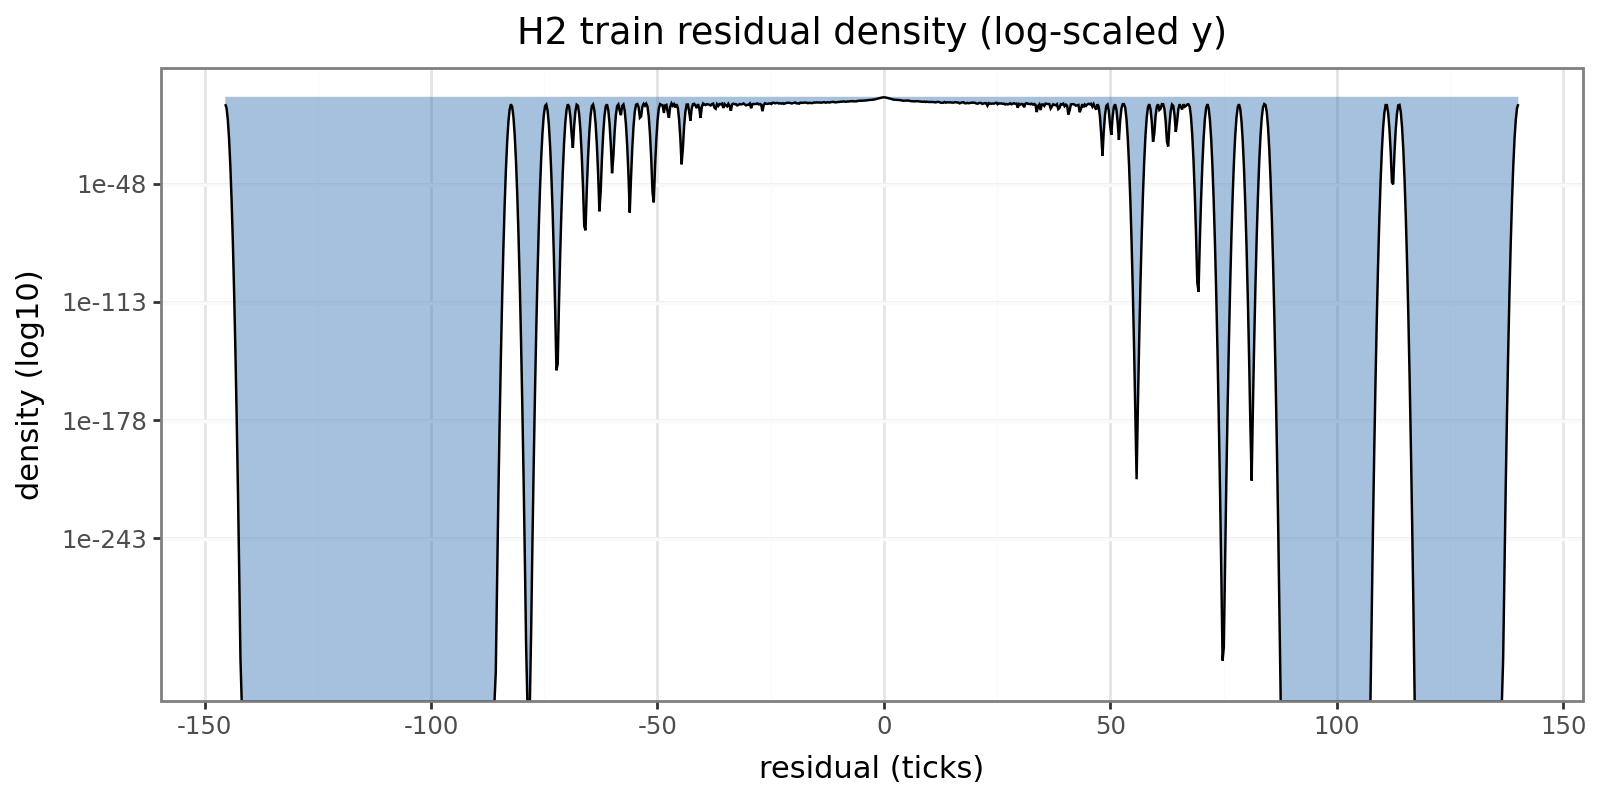

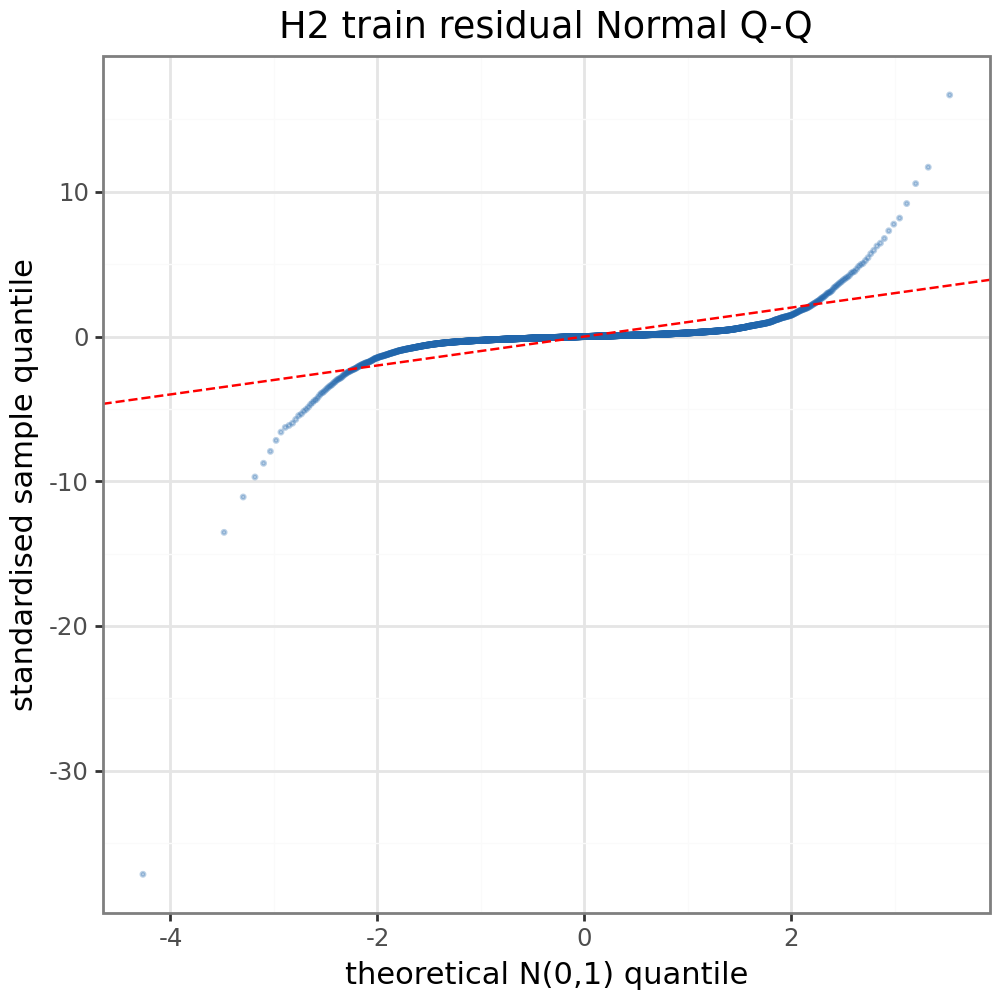

In [95]:
# --- 1. Fat-tail visualisation (TRAIN residuals) ------------------------------
_tr = resid['train']
rv  = _tr['residual'].to_numpy()

# (a) Log-scaled density: heavy tails decay slowly (near-linear) on a log y-axis.
density_plot = (
    ggplot(_tr.to_pandas(), aes(x='residual'))
    + geom_density(fill='#2166ac', alpha=0.4)
    + scale_y_log10()
    + labs(title='H2 train residual density (log-scaled y)', x='residual (ticks)', y='density (log10)')
    + theme_bw(base_size=11) + theme(figure_size=(8, 4))
)

# (b) Normal Q-Q: standardised sample quantiles vs theoretical N(0,1). Heavy tails => points bend
#     off the 45-degree line at both ends. Thinned to <=4000 points for rendering.
_n = len(rv)
_probs = (np.arange(1, _n + 1) - 0.5) / _n
qq = pl.DataFrame({
    'theoretical': stats.norm.ppf(_probs),
    'sample': (np.sort(rv) - rv.mean()) / rv.std(),
}).gather_every(max(1, _n // 4000))
qq_plot = (
    ggplot(qq.to_pandas(), aes(x='theoretical', y='sample'))
    + geom_point(size=0.4, alpha=0.3, color='#2166ac')
    + geom_abline(intercept=0, slope=1, color='red', linetype='dashed')
    + labs(title='H2 train residual Normal Q-Q', x='theoretical N(0,1) quantile',
           y='standardised sample quantile')
    + theme_bw(base_size=11) + theme(figure_size=(5, 5))
)
display(density_plot)
display(qq_plot)

In [96]:
# --- 2. Outlier concentration & attribution (TRAIN, > 4 sigma) -----------------
tr_out = resid['train'].with_columns(
    is_outlier=(pl.col('residual') - RESID_MU).abs() > OUTLIER_CUT
)
n_out_total = int(tr_out['is_outlier'].sum())
print(f'Train extreme outliers: {n_out_total:,} / {len(tr_out):,} rows '
      f'({100 * n_out_total / len(tr_out):.3f}%)')

by_security = (
    tr_out.group_by('security')
    .agg(n_rows=pl.len(), n_outliers=pl.col('is_outlier').sum())
    .with_columns(
        pct_of_all_outliers=100 * pl.col('n_outliers') / n_out_total,
        within_security_rate_pct=100 * pl.col('n_outliers') / pl.col('n_rows'),
    )
    .sort('n_outliers', descending=True)
)

by_session = (
    tr_out.group_by('security', 'date')
    .agg(n_rows=pl.len(), n_outliers=pl.col('is_outlier').sum())
    .with_columns(
        pct_of_all_outliers=100 * pl.col('n_outliers') / n_out_total,
        within_session_rate_pct=100 * pl.col('n_outliers') / pl.col('n_rows'),
    )
    .sort('n_outliers', descending=True)
)

# Concentration: how many securities carry ~80% of all outliers?
_cum = by_security.with_columns(cum_pct=pl.col('n_outliers').cum_sum() / n_out_total * 100)
n_80 = _cum.filter(pl.col('cum_pct') <= 80).height + 1
print(f'Concentration: {n_80} of {by_security.height} securities carry ~80% of outliers '
      f'(an even spread would need ~{int(0.8 * by_security.height)}).')

print('\nTop 10 most TOXIC securities:')
display(by_security.head(10))
print('Top 10 most TOXIC sessions [security, date]:')
display(by_session.head(10))

Train extreme outliers: 560 / 50,267 rows (1.114%)
Concentration: 8 of 156 securities carry ~80% of outliers (an even spread would need ~124).

Top 10 most TOXIC securities:


security,n_rows,n_outliers,pct_of_all_outliers,within_security_rate_pct
str,u32,u32,f64,f64
"""NQ2023H/2023M Index""",385,130,23.214286,33.766234
"""NQ2022Z/2023H Index""",385,82,14.642857,21.298701
"""NQ2023M/2023U Index""",385,59,10.535714,15.324675
"""NQ2023Z/2024H Index""",385,55,9.821429,14.285714
"""NQ2021Z/2022H Index""",462,43,7.678571,9.307359
"""NQ2022U/2022Z Index""",308,34,6.071429,11.038961
"""NQ2022M/2022U Index""",308,33,5.892857,10.714286
"""NQ2023U/2023Z Index""",308,29,5.178571,9.415584
"""NQ2022H/2022M Index""",462,18,3.214286,3.896104


Top 10 most TOXIC sessions [security, date]:


security,date,n_rows,n_outliers,pct_of_all_outliers,within_session_rate_pct
str,date,u32,u32,f64,f64
"""NQ2023H/2023M Index""",2023-03-15,77,34,6.071429,44.155844
"""NQ2022Z/2023H Index""",2022-12-13,77,31,5.535714,40.25974
"""NQ2022Z/2023H Index""",2022-12-15,77,28,5.0,36.363636
"""NQ2023H/2023M Index""",2023-03-16,77,26,4.642857,33.766234
"""NQ2023H/2023M Index""",2023-03-13,77,26,4.642857,33.766234
"""NQ2022U/2022Z Index""",2022-09-15,77,22,3.928571,28.571429
"""NQ2023H/2023M Index""",2023-03-10,77,22,3.928571,28.571429
"""NQ2023H/2023M Index""",2023-03-14,77,22,3.928571,28.571429
"""NQ2023Z/2024H Index""",2023-12-14,77,19,3.392857,24.675325


Spearman( |resid| , touch depth )    = -0.3339   (negative => thinner book, bigger errors)
Spearman( |resid| , spread [ticks] ) = +0.2421   (positive => wider spread, bigger errors)

|residual| & outlier rate by TOUCH-DEPTH decile (decile 1 = thinnest book):


decile,lo,hi,mean_abs_resid,median_abs_resid,outlier_rate_pct,n,metric
u32,f64,f64,f64,f64,f64,u32,str
1,2.0,111.0,6.032085,3.002591,9.568331,5027,"""depth"""
2,111.0,358.0,1.995795,0.853019,1.074199,5027,"""depth"""
3,358.0,728.0,1.181036,0.662524,0.358066,5027,"""depth"""
4,728.0,1209.0,1.009057,0.613556,0.119379,5026,"""depth"""
5,1209.0,1850.0,0.868282,0.557259,0.019893,5027,"""depth"""
6,1850.0,2739.0,0.823007,0.529136,0.0,5027,"""depth"""
7,2739.0,4031.0,0.765569,0.482335,0.0,5026,"""depth"""
8,4031.0,6029.0,0.716057,0.444852,0.0,5027,"""depth"""
9,6029.0,10115.0,0.6413,0.367314,0.0,5027,"""depth"""


|residual| & outlier rate by SPREAD decile (decile 1 = tightest):


decile,lo,hi,mean_abs_resid,median_abs_resid,outlier_rate_pct,n,metric
u32,f64,f64,f64,f64,f64,u32,str
1,2.0,2.0,0.764275,0.460655,0.039785,5027,"""spread_ticks"""
2,2.0,2.0,1.199747,0.713844,0.238711,5027,"""spread_ticks"""
3,2.0,2.0,0.712287,0.480705,0.019893,5027,"""spread_ticks"""
4,2.0,2.0,0.577212,0.346839,0.0,5026,"""spread_ticks"""
5,2.0,2.0,0.622218,0.375657,0.0,5027,"""spread_ticks"""
6,2.0,2.0,0.918586,0.568994,0.099463,5027,"""spread_ticks"""
7,2.0,2.0,0.86628,0.572164,0.019897,5026,"""spread_ticks"""
8,2.0,2.0,1.193882,0.642626,0.218818,5027,"""spread_ticks"""
9,2.0,2.0,3.049349,1.143447,3.242491,5027,"""spread_ticks"""


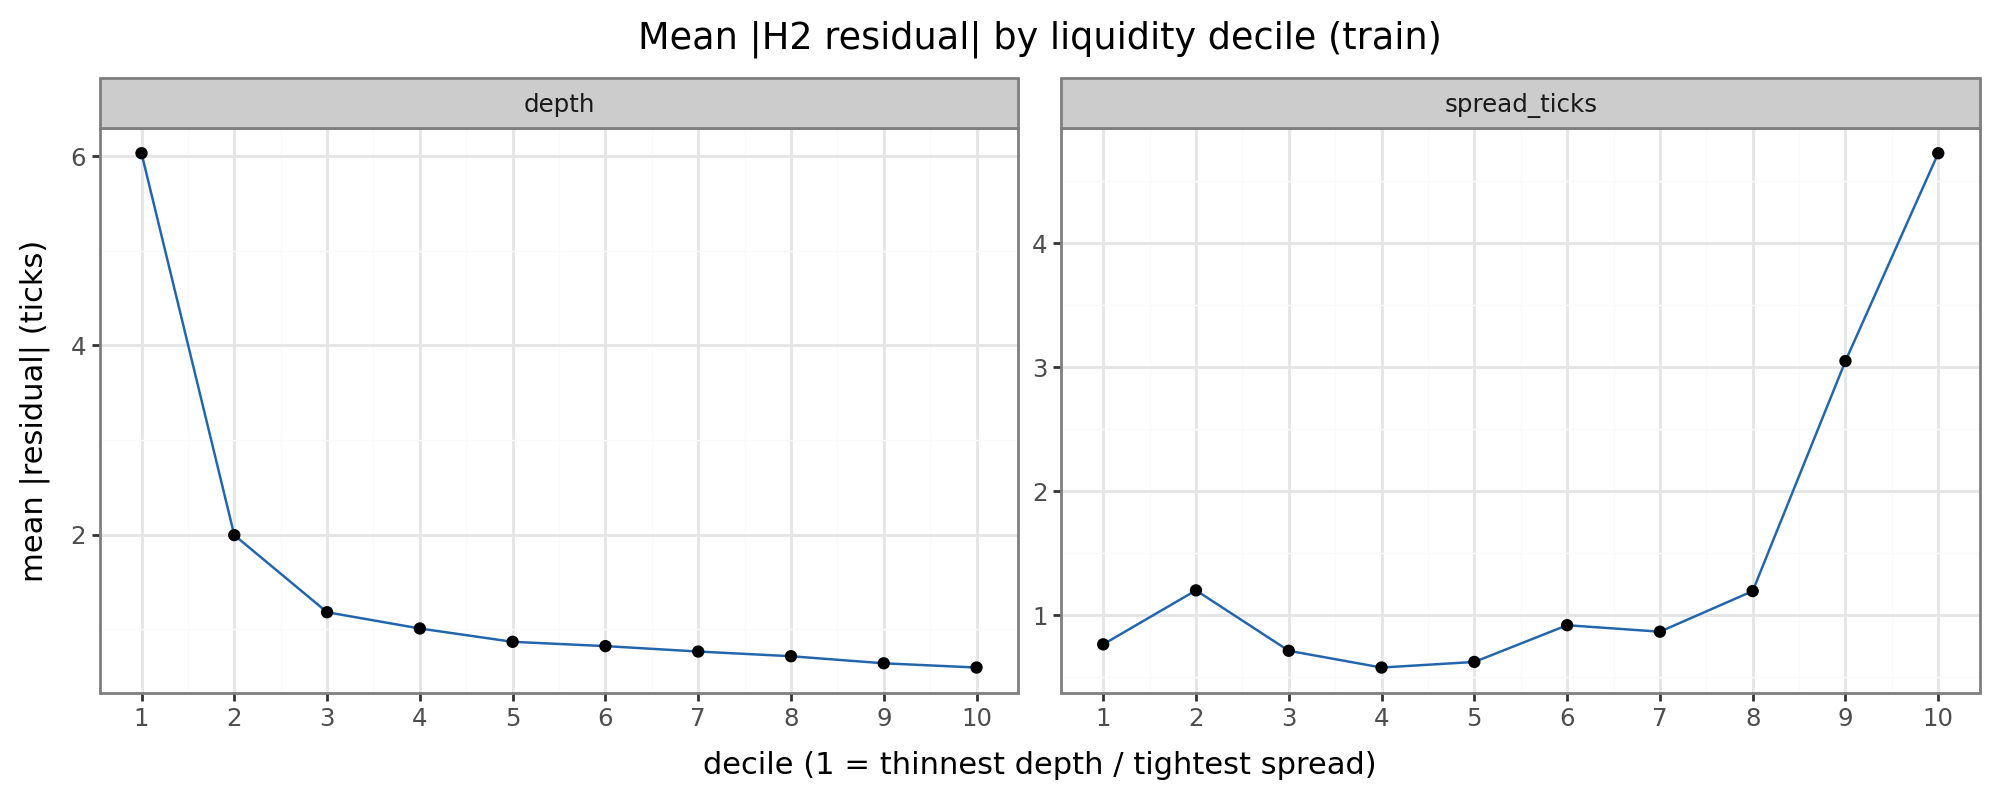

In [97]:
# --- 3. Microstructure conditioning (TRAIN): thin book / wide spread? ----------
# Pooled across the panel (cross-sectional association, not a within-contract causal effect).
micro = (
    resid['train']
    .drop_nulls(subset=['depth', 'spread_ticks'])
    .filter((pl.col('depth') > 0) & (pl.col('spread_ticks') >= 0))
)

sp_depth  = float(stats.spearmanr(micro['abs_resid'].to_numpy(), micro['depth'].to_numpy()).correlation)
sp_spread = float(stats.spearmanr(micro['abs_resid'].to_numpy(), micro['spread_ticks'].to_numpy()).correlation)
print(f'Spearman( |resid| , touch depth )    = {sp_depth:+.4f}   (negative => thinner book, bigger errors)')
print(f'Spearman( |resid| , spread [ticks] ) = {sp_spread:+.4f}   (positive => wider spread, bigger errors)')

def decile_profile(frame, col):
    """Mean/median |resid| and outlier rate across tie-safe deciles of `col` (decile 1 = smallest)."""
    return (
        frame
        .with_columns(decile=(((pl.col(col).rank(method='ordinal') - 1) * 10) // pl.len()) + 1)
        .group_by('decile')
        .agg(
            lo=pl.col(col).min(), hi=pl.col(col).max(),
            mean_abs_resid=pl.col('abs_resid').mean(),
            median_abs_resid=pl.col('abs_resid').median(),
            outlier_rate_pct=100 * ((pl.col('residual') - RESID_MU).abs() > OUTLIER_CUT).mean(),
            n=pl.len(),
        )
        .sort('decile')
        .with_columns(metric=pl.lit(col))
    )

depth_prof  = decile_profile(micro, 'depth')
spread_prof = decile_profile(micro, 'spread_ticks')
print('\n|residual| & outlier rate by TOUCH-DEPTH decile (decile 1 = thinnest book):')
display(depth_prof)
print('|residual| & outlier rate by SPREAD decile (decile 1 = tightest):')
display(spread_prof)

(
    ggplot(pl.concat([depth_prof, spread_prof]).to_pandas(), aes(x='decile', y='mean_abs_resid'))
    + geom_line(color='#2166ac') + geom_point()
    + facet_wrap('~metric', scales='free_y')
    + scale_x_continuous(breaks=list(range(1, 11)))
    + labs(title='Mean |H2 residual| by liquidity decile (train)',
           x='decile (1 = thinnest depth / tightest spread)', y='mean |residual| (ticks)')
    + theme_bw(base_size=11) + theme(figure_size=(10, 4))
)

## Segmented Models — NQ vs Others (train-winsorised)

The H2 residual diagnostics above traced ~all of the extreme kurtosis to the **NQ** curve group,
which behaves as a distinct regime. We therefore **bifurcate** the unconstrained panel into
`df_tu_nq` and `df_tu_others` (split on the raw source *before* targets are built) and fit each
segment **independently** across the three horizons.

Each segment is **winsorised with its own Train-derived bounds**: the 0.5th / 99.5th percentiles
of the target are computed on 2021–2023 rows only and then used to clip the target on Train,
Validation (2024) **and** Test (2025) — frozen, lookahead-safe, and per-segment so NQ's huge
thresholds never dilute the Others' clip. Standard errors stay cluster-robust on the
`[security, date]` session.

In [98]:
# --- Dual-segment pipeline across the three horizons (train-winsorised, clustered SE) --------
HORIZON_SPECS = [
    ('H2 contemporaneous',    'delta_p',                ['stv', 'ofi', 'obi']),
    ('H3 1-step',             'delta_p_fwd',            ['stv', 'noi', 'obi']),
    ('H3 3-step cumulative',  'delta_p_fwd_cumulative', ['stv', 'noi', 'obi']),
]

seg_models, _seg_metrics_list = {}, []
for _hlabel, _target, _feats in HORIZON_SPECS:
    for _seg_name, _seg_df in SEGMENTS.items():
        _res, _m = fit_and_evaluate(
            _target, _feats, _hlabel,
            seg_df=_seg_df, segment=_seg_name, horizon=_hlabel, winsorize=True,
        )
        seg_models[(_hlabel, _seg_name)] = _res
        _seg_metrics_list.append(_m)

# Consolidated long-format metrics: horizon | segment | split | n | R2 | RMSE | MAE
seg_metrics = (
    pd.concat(_seg_metrics_list, ignore_index=True)
    [['horizon', 'segment', 'split', 'years', 'n', 'R2', 'RMSE', 'MAE']]
)
print('Consolidated segmented metrics (train-winsorised, cluster-robust):')
print(seg_metrics.round(4).to_string(index=False))
seg_metrics

=== H2 contemporaneous [NQ]:  delta_p ~ stv + ofi + obi ===
Train obs T = 4,620 | clusters (security x date) = 60 | winsor[delta_p] in [-42.000, +48.605] (train 0.5%/99.5%)

                            OLS Regression Results                            
Dep. Variable:                delta_p   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     63.12
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           2.10e-18
Time:                        16:11:44   Log-Likelihood:                -17067.
No. Observations:                4620   AIC:                         3.414e+04
Df Residuals:                    4616   BIC:                         3.417e+04
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err    

,horizon,segment,split,years,n,R2,RMSE,MAE
0,H2 contemporaneous,NQ,train,2021-2023,4620,0.177558,9.729652,6.019231
1,H2 contemporaneous,NQ,val,2024,1309,0.184966,17.280417,12.211711
2,H2 contemporaneous,NQ,test,2025,1155,0.228554,15.255679,10.714892
3,H2 contemporaneous,Others,train,2021-2023,45647,0.201783,1.455113,0.825311
4,H2 contemporaneous,Others,val,2024,14681,0.212593,1.489871,0.846827
5,H2 contemporaneous,Others,test,2025,14515,0.198356,1.371678,0.794272
6,H3 1-step,NQ,train,2021-2023,4560,0.024326,10.464501,6.707203
7,H3 1-step,NQ,val,2024,1292,0.023664,18.681639,13.903247
8,H3 1-step,NQ,test,2025,1140,0.039789,16.896447,12.557564
9,H3 1-step,Others,train,2021-2023,45184,0.096140,1.536422,0.876154


In [99]:
# --- Wide R^2 trajectories: NQ vs Others side-by-side, per horizon ----------------------------
# train = in-sample, val/test = out-of-sample. A flat train->val->test profile (and NQ no longer
# dragging the panel) is the win we are looking for.
r2_wide = (
    seg_metrics
    .pivot_table(index='horizon', columns=['segment', 'split'], values='R2', sort=False)
    .reindex(columns=pd.MultiIndex.from_product([['NQ', 'Others'], ['train', 'val', 'test']]))
    .reindex(index=[h for h, _, _ in HORIZON_SPECS])
)
r2_wide.columns = [f'{seg}_R2_{split}' for seg, split in r2_wide.columns]
print('R^2 by horizon - NQ vs Others (train = in-sample, val/test = out-of-sample):')
r2_wide.round(4)

R^2 by horizon - NQ vs Others (train = in-sample, val/test = out-of-sample):


,NQ_R2_train,NQ_R2_val,NQ_R2_test,Others_R2_train,Others_R2_val,Others_R2_test
horizon,,,,,,
H2 contemporaneous,0.1776,0.1850,0.2286,0.2018,0.2126,0.1984
H3 1-step,0.0243,0.0237,0.0398,0.0961,0.0950,0.0919
H3 3-step cumulative,0.0123,0.0066,0.0145,0.0572,0.0500,0.0505


# Tick-constrained curve groups

Tick-constrained groups trade on a near-discrete price grid, so $\Delta P_t$ is cleaned to the
ordered set $\{-2, 0, +2\}$ (neighbour-context rules applied within each `[security, date]`
session over the full 2021-2025 sample) and modelled with a **class-weighted ordered logit**.

**Out-of-sample protocol.** Both the contemporaneous and the 1-step-ahead models are
- **trained** on 2021-2023 only, weighting the $\pm2$ minority tails by their train inverse-frequency;
- **tuned** on validation (2024) — the tail-vs-majority decision threshold is chosen to maximise
  the macro-F1 rather than using naive arg-max-probability assignment;
- **evaluated** on the held-out test set (2025) with the validation-selected threshold.

In [100]:
# --- Clean delta_p for tick-constrained securities ----------------------------
# Applied across the FULL 2021-2025 sample, within each [security, date] session.
# Rules applied simultaneously to original values:
#  1. 0, ±2: keep as-is.
#  2. ±1:
#     a. prev was ±1 (original) → 0  (this row is the "consumed" second of a prior pair)
#     b. next is ±1 same sign    → ±2 (upgrade: full-tick move)
#     c. next is ±1 opp. sign    → 0  (noise / immediate reversal)
#     d. isolated ±1             → promote to ±2
#  3. |delta_p| > 2 → clip to sign * 2.
#  4. Keep only {-2, 0, 2}.

df_signals_tc_clean = (
    df_signals_tc
    .sort(['security', 'date', 'bin_start_time'])
    .with_columns(delta_p=pl.col('delta_p').cast(pl.Int32))
    .with_columns(
        _prev_dp=pl.col('delta_p').shift(1).over(['security', 'date']),
        _next_dp=pl.col('delta_p').shift(-1).over(['security', 'date']),
    )
    .with_columns(
        delta_p=(
            pl.when(pl.col('delta_p').abs() > 2)
            # Rule 3: clip to ±2
            .then(pl.col('delta_p').sign() * 2)
            .when(pl.col('delta_p').abs() == 1)
            # Rule 2: handle ±1 based on neighbour context
            .then(
                pl.when(pl.col('_prev_dp').abs() == 1)
                # 2a: consumed by prior pair → zero
                .then(pl.lit(0))
                .when(pl.col('_next_dp').abs() == 1)
                .then(
                    pl.when(
                        ((pl.col('_next_dp') > 0) & (pl.col('delta_p') > 0)) |
                        ((pl.col('_next_dp') < 0) & (pl.col('delta_p') < 0))
                    )
                    # 2b: same sign → upgrade to ±2
                    .then(pl.col('delta_p').sign() * 2)
                    # 2c: opposite sign → zero
                    .otherwise(pl.lit(0))
                )
                # 2d: isolated → promote to ±2
                .otherwise(pl.col('delta_p') * 2)
            )
            # Rule 1: 0, ±2 unchanged
            .otherwise(pl.col('delta_p'))
        )
    )
    .drop(['_prev_dp', '_next_dp'])
    # Within-session 1-step-ahead target + chronological split key, built BEFORE the split so
    # the shift never crosses a session/year boundary (last bin of each session -> null target).
    .with_columns(
        delta_p_fwd=pl.col('delta_p').shift(-1).over(['security', 'date']),
        year=pl.col('date').dt.year(),
    )
)

counts = df_signals_tc_clean['delta_p'].value_counts(sort=True)
print(counts)

shape: (3, 2)
┌─────────┬───────┐
│ delta_p ┆ count │
│ ---     ┆ ---   │
│ i32     ┆ u32   │
╞═════════╪═══════╡
│ 0       ┆ 93165 │
│ 2       ┆ 6169  │
│ -2      ┆ 6046  │
└─────────┴───────┘


## OOS Setup & Helpers (Tick-Constrained)

`WeightedOrderedModel`, the train-derived class weight, and the shared helpers used by both
ordered-logit models below:
- `fit_weighted_olr` — fit on **train (2021-2023)** with **cluster-robust SE** (clustered on the
  `[security, date]` session, so the stacked panel does not induce spurious dependence at
  security boundaries), then predict class probabilities for train / val / test;
- `tune_threshold` — pick the macro-F1-optimal tail-vs-majority decision boundary on
  **validation (2024)**;
- `pr_threshold_df` / `confusion_tile` — plotnine precision-recall and confusion-matrix plots;
- `report_all_splits` — classification reports (precision / recall / F1 / support) per split.

In [101]:
# === OOS setup for the tick-constrained ordered-logit models ===
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve, f1_score,
)

CATS        = [-2, 0, 2]            # ordered target categories
TC_FEATURES = ['obi', 'noi', 'stv']

# Class weight on the ±2 minority tails = inverse frequency relative to the 0 class, computed
# on the TRAIN slice ONLY (deriving it from full-sample counts would leak val/test class balance
# into a training hyperparameter).
_tr_counts = (
    df_signals_tc_clean.filter(pl.col('year').is_in(TRAIN_YEARS))['delta_p'].value_counts()
)
CLASS_WEIGHT_MINOR = (
    _tr_counts.filter(pl.col('delta_p') == 0)['count'].item()
    / _tr_counts.filter(pl.col('delta_p') == 2)['count'].item()
)
print(f'Train class weight on +/-2 tails (count[0] / count[+2]) = {CLASS_WEIGHT_MINOR:.1f}x')


class WeightedOrderedModel(OrderedModel):
    """OrderedModel with per-observation class weights. Overriding loglikeobs propagates the
    weights into both the optimisation objective and the score_obs used by the robust sandwich."""

    def __init__(self, endog, exog, obs_weights=None, **kwargs):
        super().__init__(endog, exog, **kwargs)
        n = len(np.asarray(endog))
        self._obs_weights = (
            np.ones(n) if obs_weights is None else np.asarray(obs_weights, dtype=float)
        )

    def loglikeobs(self, params):
        return super().loglikeobs(params) * self._obs_weights


def _tc_frame(target_col, feature_cols, years):
    """Materialise a chronological slice of the cleaned tick-constrained data to pandas ONCE,
    carrying the target, the features, and a `cluster` key = security|date (the intraday
    session). Row order [security, date, bin_start_time] is preserved."""
    pdf = (
        df_signals_tc_clean
        .filter(pl.col('year').is_in(years))
        .select([target_col, *feature_cols, 'security', 'date'])
        .drop_nulls()
        .to_pandas()
    )
    pdf['cluster'] = pdf['security'].astype(str) + '|' + pdf['date'].astype(str)
    return pdf


def fit_weighted_olr(target_col, feature_cols, label):
    """Fit the class-weighted ordered logit on TRAIN (2021-2023) with CLUSTER-ROBUST SE
    (clustered on the [security, date] session — see note: a linear HAC across the stacked panel
    would fabricate dependence at security boundaries), then return (result, {split: (y_int,
    probs)}) with predicted class probabilities for each split."""
    tr     = _tc_frame(target_col, feature_cols, TRAIN_YEARS)
    y_tr   = tr[target_col].astype(int).values
    endog  = pd.Categorical(y_tr, categories=CATS, ordered=True)
    weights = np.where(y_tr == 0, 1.0, CLASS_WEIGHT_MINOR)

    res = WeightedOrderedModel(endog, tr[feature_cols], obs_weights=weights, distr='logit').fit(
        method='bfgs', cov_type='cluster', cov_kwds={'groups': tr['cluster'].values}, disp=False,
    )
    print(f'=== {label}:  {target_col} ~ {" + ".join(feature_cols)}  '
          f'(train 2021-2023, n={len(tr):,}, clusters={tr["cluster"].nunique():,}) ===')
    print('train class counts:', dict(pd.Series(y_tr).value_counts().reindex(CATS).items()))
    print(res.summary())

    out = {}
    for name, years in (('train', TRAIN_YEARS), ('val', VAL_YEARS), ('test', TEST_YEARS)):
        fr = _tc_frame(target_col, feature_cols, years)
        out[name] = (fr[target_col].astype(int).values, np.asarray(res.predict(exog=fr[feature_cols])))
    return res, out


def assign_classes(probs, thr):
    """Tail-vs-majority decision rule: +2 if P(+2) >= thr, else -2 if P(-2) >= thr, else 0.
    `probs` columns are ordered as CATS = [-2, 0, +2]."""
    return np.where(probs[:, 2] >= thr, 2, np.where(probs[:, 0] >= thr, -2, 0))


def tune_threshold(y_val, probs_val, grid=None):
    """Choose the single decision threshold maximising macro-F1 over {-2, 0, +2} on the
    VALIDATION set. Returns (best_thr, best_macro_f1, sweep_dataframe)."""
    if grid is None:
        grid = np.round(np.linspace(0.10, 0.95, 171), 4)
    rows = [(thr, f1_score(y_val, assign_classes(probs_val, thr),
                           labels=CATS, average='macro', zero_division=0)) for thr in grid]
    sweep = pd.DataFrame(rows, columns=['Threshold', 'MacroF1'])
    best  = sweep.loc[sweep['MacroF1'].idxmax()]
    return float(best['Threshold']), float(best['MacroF1']), sweep


def pr_threshold_df(y_val, probs_val):
    """Tidy precision/recall-vs-threshold for the two tail classes (validation data)."""
    frames = []
    for cls, col in ((-2, 0), (2, 2)):
        prec, rec, thr = precision_recall_curve((y_val == cls).astype(int), probs_val[:, col])
        frames.append(pd.DataFrame({
            'Threshold': thr, 'Precision': prec[:-1], 'Recall': rec[:-1], 'Class': f'Class {cls:+d}',
        }))
    return pd.concat(frames, ignore_index=True).melt(
        id_vars=['Threshold', 'Class'], value_vars=['Precision', 'Recall'],
        var_name='Metric', value_name='Value',
    )


def report_all_splits(data, thr, label):
    """Print classification reports (precision / recall / F1 / support) at `thr` for every split."""
    for name in ('train', 'val', 'test'):
        y, probs = data[name]
        pred = assign_classes(probs, thr)
        print(f'\n--- {label} | {name} ({YEAR_LABEL[name]}) | thr={thr:.3f} | '
              f'accuracy={(pred == y).mean():.4f} | n={len(y):,} ---')
        print(classification_report(y, pred, labels=CATS,
                                    target_names=['-2', '0', '+2'], zero_division=0))


def confusion_tile(y_true, y_pred, title):
    """plotnine confusion-matrix heatmap with raw counts and row percentages."""
    cm = confusion_matrix(y_true, y_pred, labels=CATS)
    cm_long = (
        pd.DataFrame(cm, index=CATS, columns=CATS)
        .rename_axis('Actual').reset_index()
        .melt(id_vars='Actual', var_name='Predicted', value_name='n')
        .assign(
            row_pct=lambda d: 100 * d['n'] / d.groupby('Actual')['n'].transform('sum'),
            label=lambda d: d.apply(lambda r: f"{int(r['n'])}\n({r['row_pct']:.1f}%)", axis=1),
        )
    )
    for col, order in [('Predicted', ['-2', '0', '2']), ('Actual', ['2', '0', '-2'])]:
        cm_long[col] = pd.Categorical(cm_long[col].astype(str), categories=order)
    return (
        ggplot(cm_long, aes(x='Predicted', y='Actual', fill='row_pct'))
        + geom_tile(color='white', size=0.5)
        + geom_text(aes(label='label'), size=9)
        + scale_fill_gradient(low='#f0f4ff', high='#2166ac', name='Row %')
        + labs(title=title, x='Predicted ΔP', y='Actual ΔP')
        + theme_bw(base_size=11) + theme(figure_size=(5, 4))
    )

Train class weight on +/-2 tails (count[0] / count[+2]) = 11.8x


## Contemporary Baseline: Ordered Logistic Regression (Tick-Constrained)

Class-weighted ordered logit with **cluster-robust** standard errors (clustered on the
`[security, date]` session, not a linear HAC across the stacked panel), **fit on train (2021-2023)**:

$$\Pr(\Delta P_t \le k) = \sigma(\alpha_k - \mathbf{x}_t^\top \boldsymbol{\beta}), \quad k \in \{-2, 0\}$$

Explanatory variables $\mathbf{x}_t = [OBI_t,\ NOI_t,\ STV_t]$; target $\Delta P_t \in \{-2, 0, 2\}$.
The tail-vs-majority decision threshold is tuned on validation (2024) and applied to test (2025).

In [102]:
# --- Contemporary baseline: fit the class-weighted ordered logit on TRAIN (2021-2023) ---
# Features OBI, NOI, STV (no constant — ordered logit estimates the cut-points instead).
res_contemp, data_contemp = fit_weighted_olr('delta_p', TC_FEATURES, 'Contemporaneous (tick-constrained)')

=== Contemporaneous (tick-constrained):  delta_p ~ obi + noi + stv  (train 2021-2023, n=64,211, clusters=602) ===
train class counts: {-2: 4523, 0: 55038, 2: 4650}
                          WeightedOrderedModel Results                          
Dep. Variable:                        y   Log-Likelihood:                -93303.
Model:             WeightedOrderedModel   AIC:                         1.866e+05
Method:              Maximum Likelihood   BIC:                         1.867e+05
Date:                  Wed, 10 Jun 2026                                         
Time:                          16:11:46                                         
No. Observations:                 64211                                         
Df Residuals:                     64206                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------

Validation-optimal PROB_THRESH = 0.845  (val macro-F1 = 0.6043  vs  arg-max-prob = 0.4578)


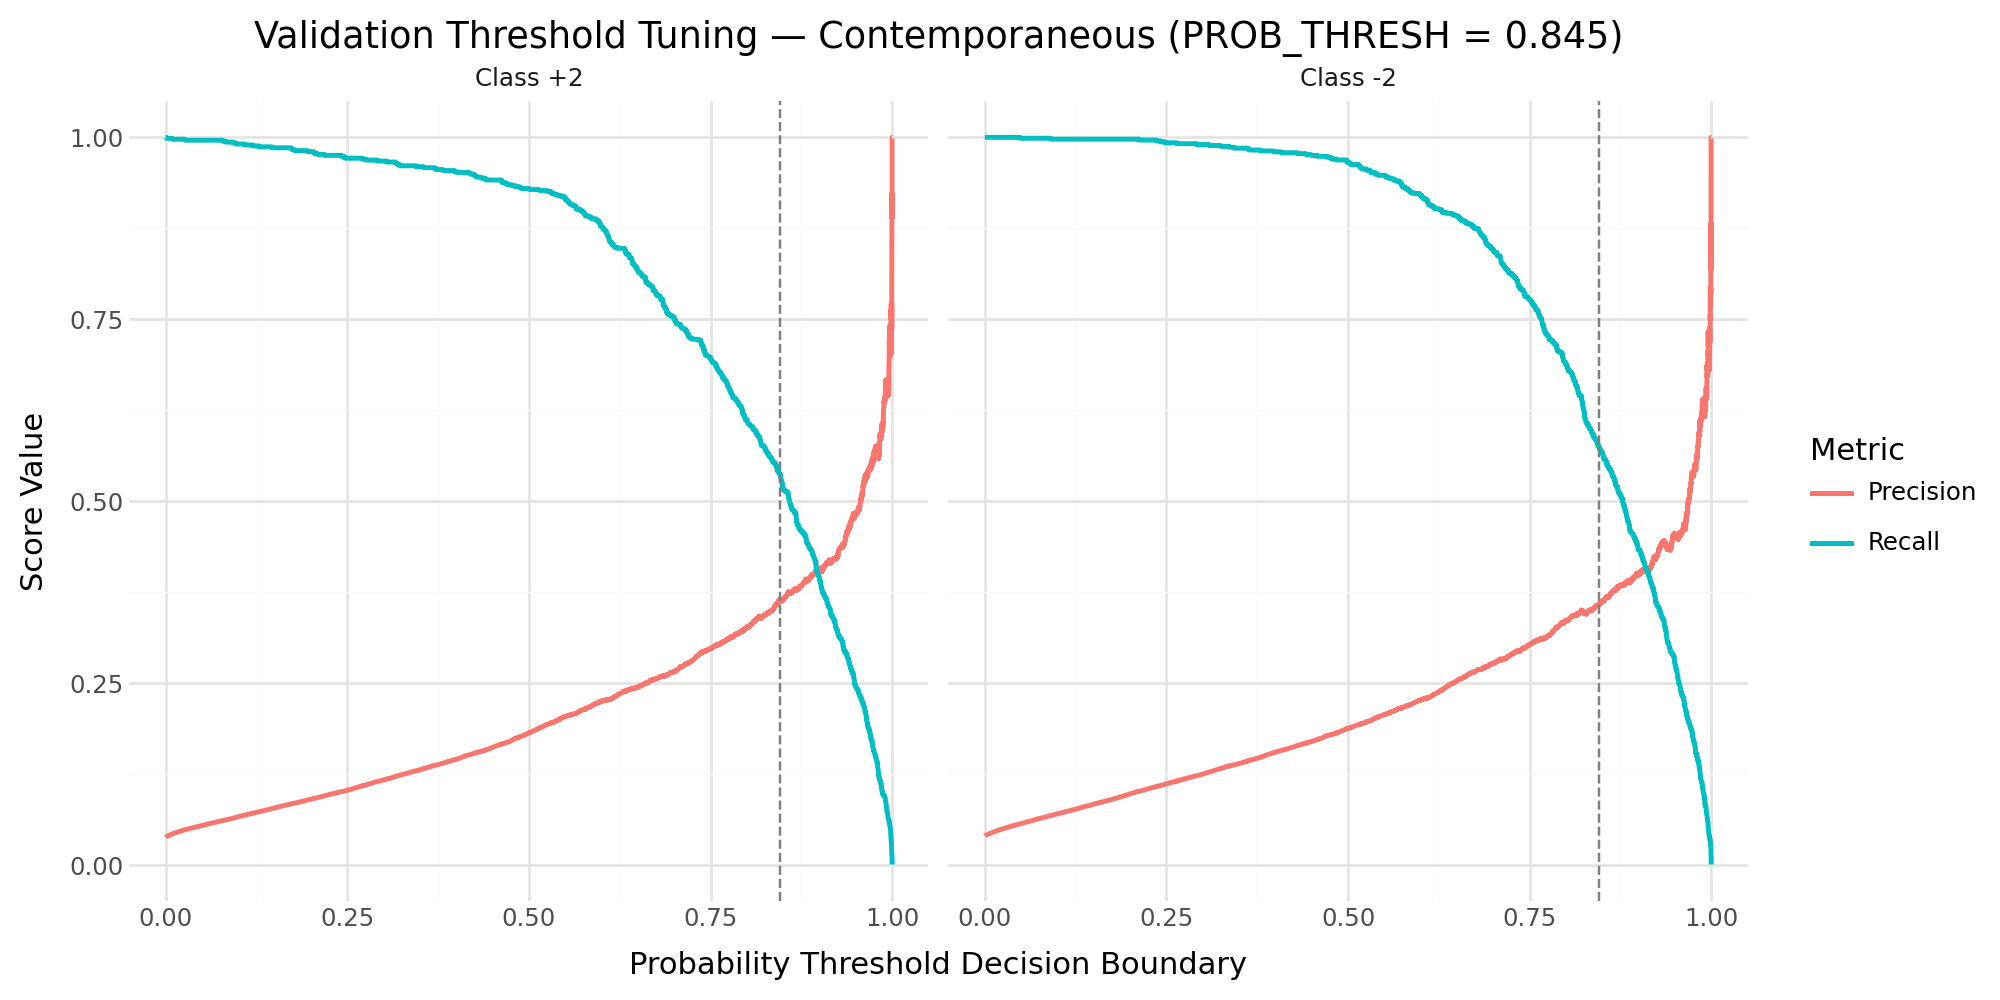

In [103]:
# --- Tune the decision threshold on VALIDATION (2024) -----------------------
# Sweep the tail-vs-majority boundary to maximise macro-F1; compare to naive arg-max-prob.
y_val_c, probs_val_c = data_contemp['val']

PROB_THRESH, best_f1_c, sweep_c = tune_threshold(y_val_c, probs_val_c)
argmax_f1_c = f1_score(y_val_c, np.array(CATS)[probs_val_c.argmax(1)],
                       labels=CATS, average='macro', zero_division=0)
print(f'Validation-optimal PROB_THRESH = {PROB_THRESH:.3f}  '
      f'(val macro-F1 = {best_f1_c:.4f}  vs  arg-max-prob = {argmax_f1_c:.4f})')

# Precision/Recall vs threshold on VALIDATION, with the selected boundary marked.
pr_long_c = pr_threshold_df(y_val_c, probs_val_c)
(
    ggplot(pr_long_c, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(xintercept=PROB_THRESH, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Contemporaneous (PROB_THRESH = {PROB_THRESH:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)


--- Contemporaneous | train (2021-2023) | thr=0.845 | accuracy=0.8551 | n=64,211 ---
              precision    recall  f1-score   support

          -2       0.51      0.42      0.46      4523
           0       0.91      0.93      0.92     55038
          +2       0.47      0.44      0.46      4650

    accuracy                           0.86     64211
   macro avg       0.63      0.60      0.61     64211
weighted avg       0.85      0.86      0.85     64211


--- Contemporaneous | val (2024) | thr=0.845 | accuracy=0.8869 | n=19,873 ---
              precision    recall  f1-score   support

          -2       0.36      0.58      0.44       805
           0       0.96      0.92      0.94     18300
          +2       0.36      0.54      0.43       768

    accuracy                           0.89     19873
   macro avg       0.56      0.68      0.60     19873
weighted avg       0.91      0.89      0.90     19873


--- Contemporaneous | test (2025) | thr=0.845 | accuracy=0.8867 | n=20,3

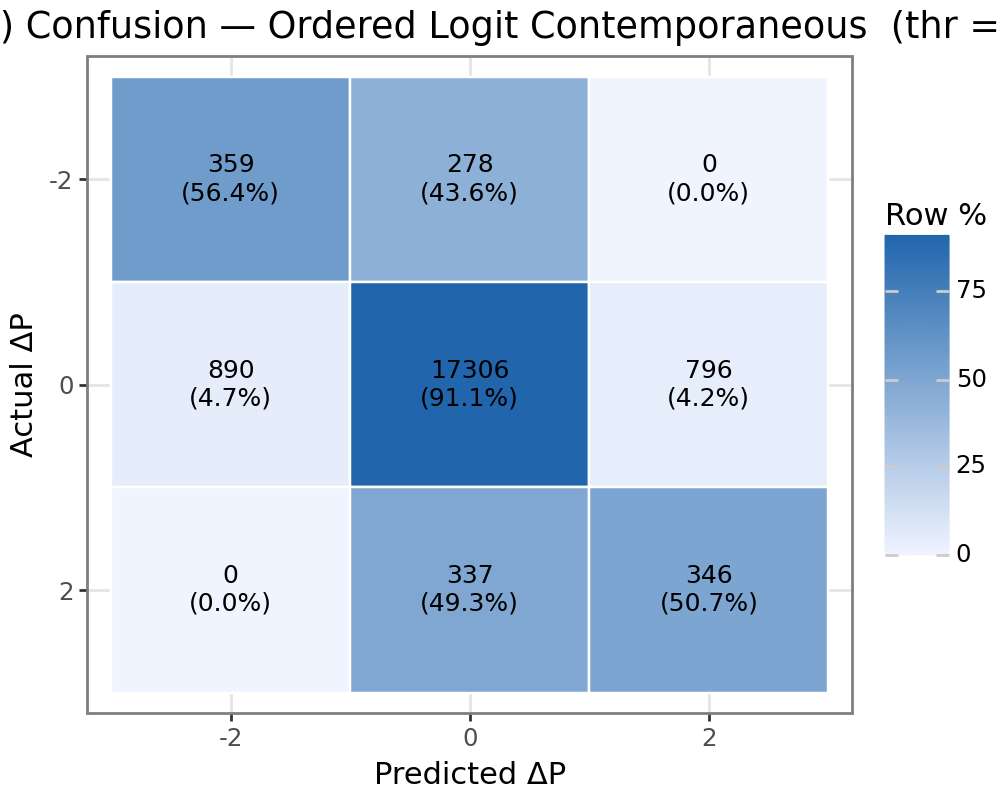

In [104]:
# --- Apply the validation-tuned threshold: reports for all splits + TEST confusion matrix ---
# Train / val / test classification reports at the SAME validation-selected PROB_THRESH,
# then the held-out 2025 confusion matrix (raw counts + row %).
report_all_splits(data_contemp, PROB_THRESH, 'Contemporaneous')

y_test_c, probs_test_c = data_contemp['test']
confusion_tile(
    y_test_c, assign_classes(probs_test_c, PROB_THRESH),
    title=f'Test (2025) Confusion — Ordered Logit Contemporaneous  (thr = {PROB_THRESH:.3f})',
)

## Predictive Model: Ordered Logistic Regression (1-Step-Ahead)

Identical class-weighted ordered logit, but the target is $\Delta P_{t+1}$ — the next bin's
**cleaned** price change, shifted into the current row with `.shift(-1).over(['security', 'date'])`
in the cleaning step (before the split), so there is no look-ahead leakage across sessions or
years. Trained on 2021-2023, threshold tuned on validation (2024), evaluated on test (2025).

In [105]:
# --- Predictive 1-step-ahead: fit the class-weighted ordered logit on TRAIN (2021-2023) ---
# Target delta_p_fwd = next bin's cleaned delta_p, built within each [security, date] session
# in the cleaning cell (before the split) — no look-ahead across sessions or year boundaries.
res_fwd, data_fwd = fit_weighted_olr('delta_p_fwd', TC_FEATURES, 'Predictive 1-step (tick-constrained)')

=== Predictive 1-step (tick-constrained):  delta_p_fwd ~ obi + noi + stv  (train 2021-2023, n=63,609, clusters=602) ===
train class counts: {-2: 4490, 0: 54509, 2: 4610}
                          WeightedOrderedModel Results                          
Dep. Variable:                        y   Log-Likelihood:            -1.2973e+05
Model:             WeightedOrderedModel   AIC:                         2.595e+05
Method:              Maximum Likelihood   BIC:                         2.595e+05
Date:                  Wed, 10 Jun 2026                                         
Time:                          16:11:48                                         
No. Observations:                 63609                                         
Df Residuals:                     63604                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------

Validation-optimal THRESH_FWD = 0.745  (val macro-F1 = 0.6006  vs  arg-max-prob = 0.4019)


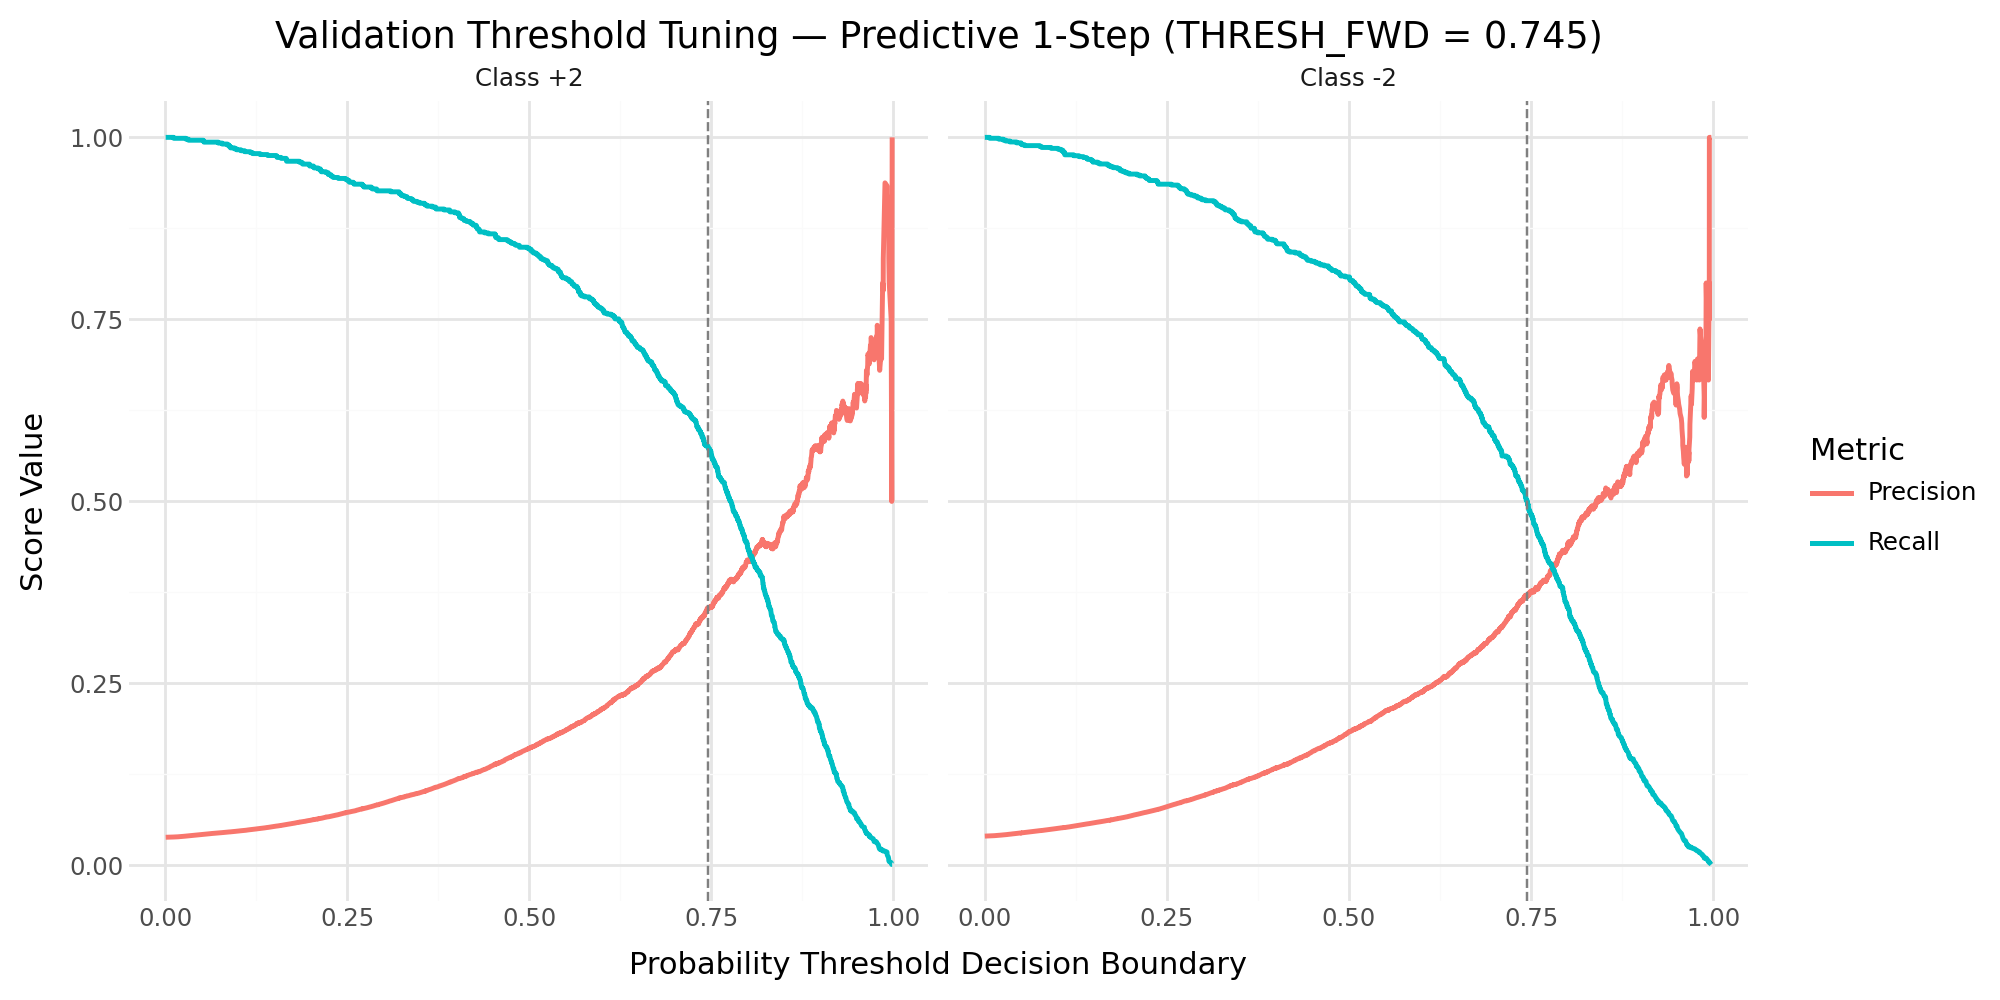

In [106]:
# --- Tune the predictive decision threshold on VALIDATION (2024) ------------
y_val_f, probs_val_f = data_fwd['val']

THRESH_FWD, best_f1_f, sweep_f = tune_threshold(y_val_f, probs_val_f)
argmax_f1_f = f1_score(y_val_f, np.array(CATS)[probs_val_f.argmax(1)],
                       labels=CATS, average='macro', zero_division=0)
print(f'Validation-optimal THRESH_FWD = {THRESH_FWD:.3f}  '
      f'(val macro-F1 = {best_f1_f:.4f}  vs  arg-max-prob = {argmax_f1_f:.4f})')

# Precision/Recall vs threshold on VALIDATION, with the selected boundary marked.
pr_long_f = pr_threshold_df(y_val_f, probs_val_f)
(
    ggplot(pr_long_f, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + geom_vline(xintercept=THRESH_FWD, linetype='dashed', color='grey')
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title=f'Validation Threshold Tuning — Predictive 1-Step (THRESH_FWD = {THRESH_FWD:.3f})',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric',
    )
    + theme(figure_size=(10, 5))
)


--- Predictive 1-step | train (2021-2023) | thr=0.745 | accuracy=0.8271 | n=63,609 ---
              precision    recall  f1-score   support

          -2       0.36      0.34      0.35      4490
           0       0.89      0.91      0.90     54509
          +2       0.39      0.35      0.37      4610

    accuracy                           0.83     63609
   macro avg       0.55      0.53      0.54     63609
weighted avg       0.82      0.83      0.82     63609


--- Predictive 1-step | val (2024) | thr=0.745 | accuracy=0.8888 | n=19,684 ---
              precision    recall  f1-score   support

          -2       0.37      0.50      0.42       793
           0       0.96      0.92      0.94     18129
          +2       0.35      0.58      0.44       762

    accuracy                           0.89     19684
   macro avg       0.56      0.66      0.60     19684
weighted avg       0.91      0.89      0.90     19684


--- Predictive 1-step | test (2025) | thr=0.745 | accuracy=0.8879 | 

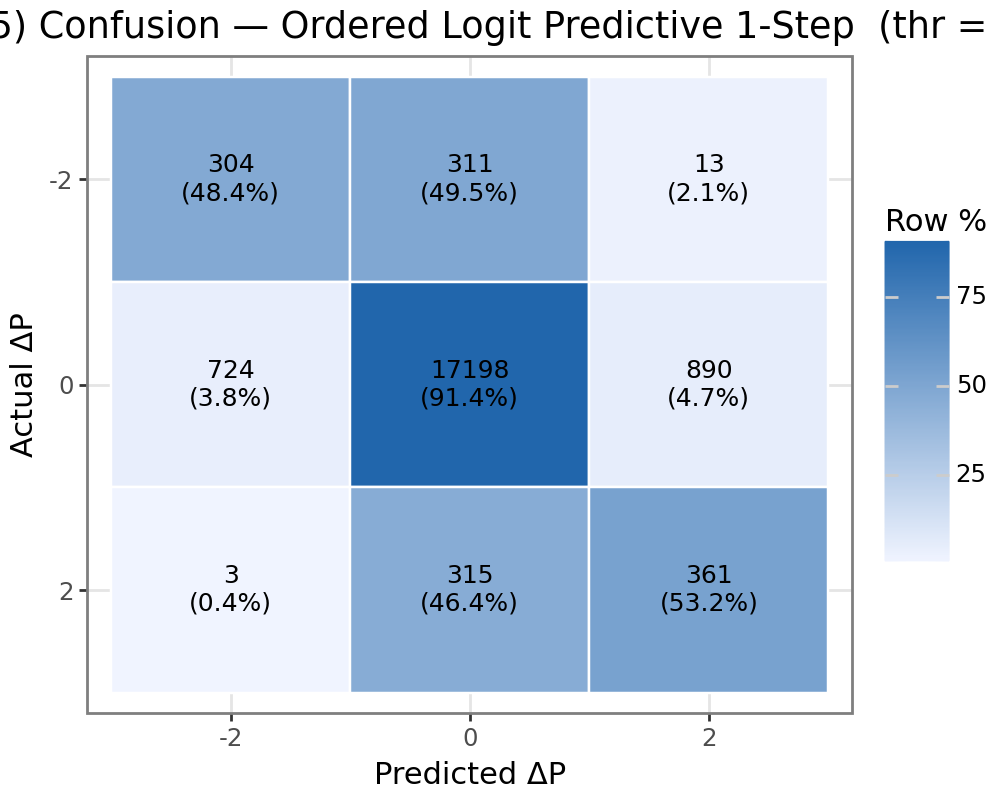

In [107]:
# --- Apply the validation-tuned threshold: reports for all splits + TEST confusion matrix ---
report_all_splits(data_fwd, THRESH_FWD, 'Predictive 1-step')

y_test_f, probs_test_f = data_fwd['test']
confusion_tile(
    y_test_f, assign_classes(probs_test_f, THRESH_FWD),
    title=f'Test (2025) Confusion — Ordered Logit Predictive 1-Step  (thr = {THRESH_FWD:.3f})',
)